In [1]:
import os
from typing import Callable, Optional, Sequence, List, Dict, Any

import numpy as np
import pandas as pd

# =========================
# 1) Feature blocks to keep
# =========================
B0_SUMMARY = []

B0_TURNS = [
    "words_per_min",
    "speech_percentage",
    "mean_pause_length",
    "pause_variability",
    "word_repeat_percentage",
    "phrase_repeat_percentage",
    "turn_length_words",
]

# ---- L: language-dependent ----
L_SUMMARY = [
    "word_coherence_mean",
    "word_coherence_10_mean",
    "semantic_perplexity_mean",
    "semantic_perplexity_5_mean",
    "first_order_sentence_tangeniality_mean",
]

L_TURNS = [
    "syllables_per_min",
    "sentiment_neg",
    "sentiment_pos",
    "sentiment_overall",
    "mattr_10",
    "mattr_50",
    "first_person_percentage",
    "first_person_sentiment_negative",
]
LANGUAGE = "eng" # "ukr"
ITERATION = '3'

# =========================
# 2) One function (similar to yours)
# =========================

def _unique_preserve_order(items: Sequence[str]) -> List[str]:
    seen = set()
    out = []
    for x in items:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out


def merge_turns_and_summary_featureblock(
    detailed_labels_path: str,
    data_dir: str,
    *,
    participant_col: str = "Participant",
    turns_cols: Optional[List[str]] = None,
    summary_cols: Optional[List[str]] = None,
    turns_prefix: str = "turns_",
    summary_prefix: str = "summary_sc_",
    turns_suffix: str = ".csv",
    summary_suffix: str = ".csv",
    turns_agg: str | Callable[[pd.Series], Any] = "mean",   # "mean" | "first" | callable
    resolve_name_collisions: bool = True,                  # prevent overwriting when col exists in both
    turns_collision_suffix: str = "_turns",
    summary_collision_suffix: str = "_summary",
    # optional: if your turns files still include speaker rows, set these
    turns_speaker_col: Optional[str] = None,               # e.g. "speaker_label"
    participant_speaker_value: Optional[str] = None,       # e.g. "Participant"
    verbose: bool = False,
) -> pd.DataFrame:
    """
    Merge specified feature columns from turns_<pid>.csv and summary_sc_<pid>.csv into the labels table.
    - Aggregates turns columns per participant (default: mean).
    - Takes summary columns from the first row (file-level).
    - Resolves name collisions by suffixing if requested.
    """
    if os.path.isfile(data_dir):
        data_dir = os.path.dirname(data_dir)
    if not os.path.isdir(data_dir):
        raise FileNotFoundError(f"Directory not found: {data_dir}")

    df_labels = pd.read_csv(detailed_labels_path)
    df_labels[participant_col] = pd.to_numeric(df_labels[participant_col], errors="coerce").astype("Int64")

    pids = df_labels[participant_col].dropna().unique().astype(int)

    # keep list order stable, remove duplicates
    turns_cols = _unique_preserve_order(turns_cols or [])
    summary_cols = _unique_preserve_order(summary_cols or [])

    rows: List[Dict[str, Any]] = []
    for pid in pids:
        rec: Dict[str, Any] = {participant_col: pid}

        # ---------- turns_<pid>.csv ----------
        t_path = os.path.join(data_dir, f"{turns_prefix}{pid}{turns_suffix}")
        if os.path.exists(t_path) and turns_cols:
            t_header = pd.read_csv(t_path, nrows=0).columns.tolist()
            t_use = [c for c in turns_cols if c in t_header]

            # ensure speaker column is included if filtering is requested
            if turns_speaker_col and turns_speaker_col in t_header and turns_speaker_col not in t_use:
                t_use_with_speaker = [turns_speaker_col] + t_use
            else:
                t_use_with_speaker = t_use

            if t_use:
                t_df = pd.read_csv(t_path, usecols=t_use_with_speaker)

                # optional speaker filtering
                if turns_speaker_col and participant_speaker_value is not None and turns_speaker_col in t_df.columns:
                    t_df = t_df[t_df[turns_speaker_col] == participant_speaker_value].copy()

                # aggregate
                t_vals: Dict[str, Any] = {}
                if callable(turns_agg):
                    for c in t_use:
                        t_vals[c] = turns_agg(t_df[c])
                elif turns_agg == "mean":
                    for c in t_use:
                        col = pd.to_numeric(t_df[c], errors="coerce")
                        t_vals[c] = float(col.mean()) if len(col) else np.nan
                elif turns_agg == "first":
                    for c in t_use:
                        t_vals[c] = t_df[c].iloc[0] if len(t_df) else np.nan
                else:
                    raise ValueError(f"Unsupported turns_agg: {turns_agg!r}")

                # collision-safe naming (prevents overwriting later)
                if resolve_name_collisions:
                    renamed = {}
                    for k, v in t_vals.items():
                        out_k = k if k not in rec else f"{k}{turns_collision_suffix}"
                        renamed[out_k] = v
                    t_vals = renamed

                rec.update(t_vals)
            elif verbose:
                print(f"[pid={pid}] turns file exists but none of requested cols found.")

        # ---------- summary_sc_<pid>.csv ----------
        s_path = os.path.join(data_dir, f"{summary_prefix}{pid}{summary_suffix}")
        if os.path.exists(s_path) and summary_cols:
            s_header = pd.read_csv(s_path, nrows=0).columns.tolist()
            s_use = [c for c in summary_cols if c in s_header]
            if s_use:
                s_df = pd.read_csv(s_path, usecols=s_use)
                s_vals = {c: (s_df[c].iloc[0] if len(s_df) else np.nan) for c in s_use}

                # collision-safe naming
                if resolve_name_collisions:
                    renamed = {}
                    for k, v in s_vals.items():
                        out_k = k if k not in rec else f"{k}{summary_collision_suffix}"
                        renamed[out_k] = v
                    s_vals = renamed

                rec.update(s_vals)
            elif verbose:
                print(f"[pid={pid}] summary file exists but none of requested cols found.")

        rows.append(rec)

    df_feat = pd.DataFrame(rows)
    df_out = df_labels.merge(df_feat, on=participant_col, how="left")
    return df_out

# =========================
# 3) Build 3 datasets by calling the same function
# =========================

def _union(a: List[str], b: List[str]) -> List[str]:
    return _unique_preserve_order(list(a) + list(b))

In [2]:


# Paths (edit)
detailed_labels_path = "/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/detailed_lables.csv"
data_dir = f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/result_oppenwillis_{LANGUAGE}_norm"

# Columns you always want in the final CSVs (spine)
SPINE_COLS = ["Participant", "gender", "age", "split", "Depression_label", "PTSD_label", "PTSD_severity", "Depression_severity"]

# --- L ---
df_l = merge_turns_and_summary_featureblock(
    detailed_labels_path=detailed_labels_path,
    data_dir=data_dir,
    participant_col="Participant",
    turns_cols=L_TURNS,
    summary_cols=L_SUMMARY,
    turns_agg="mean",
    resolve_name_collisions=True,
)

L_OUT_COLS = [c for c in df_l.columns if c in SPINE_COLS] + \
            [c for c in df_l.columns if (c in L_TURNS or c.endswith("_turns"))] + \
            [c for c in df_l.columns if (c in L_SUMMARY or c.endswith("_summary"))]

df_l_out = df_l[_unique_preserve_order(L_OUT_COLS)].copy()
df_l_out.to_csv(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_{LANGUAGE}_small_test{ITERATION}.csv",
    index=False
)
print("df_l columns - ", df_l_out.columns)

# --- B0 ---
df_b0 = merge_turns_and_summary_featureblock(
    detailed_labels_path=detailed_labels_path,
    data_dir=data_dir,
    participant_col="Participant",
    turns_cols=B0_TURNS,
    summary_cols=B0_SUMMARY,
    turns_agg="mean",
    resolve_name_collisions=True,  # keeps both turns+summary if same name exists
)

b0_feature_cols = _unique_preserve_order(
    [c for c in df_b0.columns if c not in df_b0.columns.difference(df_b0.columns)]  # noop, keep below
)
# safer: explicitly compute expected output cols by checking presence
B0_OUT_COLS = [c for c in df_b0.columns if c in SPINE_COLS] + \
             [c for c in df_b0.columns if (c in B0_TURNS or c.endswith("_turns"))] + \
             [c for c in df_b0.columns if (c in B0_SUMMARY or c.endswith("_summary"))]

df_b0_out = df_b0[_unique_preserve_order(B0_OUT_COLS)].copy()
df_b0_out.to_csv(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_{LANGUAGE}_small_test{ITERATION}.csv",
    index=False
)
print("df_b0 columns - ", df_b0_out.columns)

# --- B0 + L ---
df_b0l = merge_turns_and_summary_featureblock(
    detailed_labels_path=detailed_labels_path,
    data_dir=data_dir,
    participant_col="Participant",
    turns_cols=_union(B0_TURNS, L_TURNS),
    summary_cols=_union(B0_SUMMARY, L_SUMMARY),
    turns_agg="mean",
    resolve_name_collisions=True,
)

B0L_OUT_COLS = [c for c in df_b0l.columns if c in SPINE_COLS] + \
              [c for c in df_b0l.columns if (c in _union(B0_TURNS, L_TURNS) or c.endswith("_turns"))] + \
              [c for c in df_b0l.columns if (c in _union(B0_SUMMARY, L_SUMMARY) or c.endswith("_summary"))]

df_b0l_out = df_b0l[_unique_preserve_order(B0L_OUT_COLS)].copy()
df_b0l_out.to_csv(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_{LANGUAGE}_full{ITERATION}.csv",
    index=False
)
print("df l+b0 columns ", df_b0l_out.columns)

df_l columns -  Index(['Participant', 'Depression_severity', 'PTSD_severity', 'gender', 'age',
       'Depression_label', 'PTSD_label', 'split', 'syllables_per_min',
       'sentiment_neg', 'sentiment_pos', 'sentiment_overall', 'mattr_10',
       'mattr_50', 'first_person_percentage',
       'first_person_sentiment_negative', 'word_coherence_mean',
       'word_coherence_10_mean', 'semantic_perplexity_mean',
       'semantic_perplexity_5_mean', 'first_order_sentence_tangeniality_mean'],
      dtype='object')
df_b0 columns -  Index(['Participant', 'Depression_severity', 'PTSD_severity', 'gender', 'age',
       'Depression_label', 'PTSD_label', 'split', 'words_per_min',
       'speech_percentage', 'mean_pause_length', 'pause_variability',
       'word_repeat_percentage', 'phrase_repeat_percentage',
       'turn_length_words'],
      dtype='object')
df l+b0 columns  Index(['Participant', 'Depression_severity', 'PTSD_severity', 'gender', 'age',
       'Depression_label', 'PTSD_label', 'spl

In [3]:
import warnings
warnings.filterwarnings("ignore")

from typing import Optional, Sequence, Dict, Any, List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, average_precision_score,
    balanced_accuracy_score, brier_score_loss, classification_report, confusion_matrix
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, GridSearchCV, cross_val_score

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
xgb_available = True


# -------------------------
# Bootstrap CIs
# -------------------------
def bootstrap_ci_binary(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_proba: np.ndarray,
    metric: str,
    n_boot: int = 2000,
    seed: int = 1706,
    stratified: bool = True,
) -> Tuple[float, float, float]:
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_proba = np.asarray(y_proba)

    idx_pos = np.where(y_true == 1)[0]
    idx_neg = np.where(y_true == 0)[0]
    if len(idx_pos) == 0 or len(idx_neg) == 0:
        return float("nan"), float("nan"), float("nan")

    scores = []
    for _ in range(n_boot):
        if stratified:
            samp_pos = rng.choice(idx_pos, size=len(idx_pos), replace=True)
            samp_neg = rng.choice(idx_neg, size=len(idx_neg), replace=True)
            idx = np.concatenate([samp_pos, samp_neg])
        else:
            idx = rng.choice(len(y_true), size=len(y_true), replace=True)

        yt, yp, pr = y_true[idx], y_pred[idx], y_proba[idx]
        if metric == "f1_macro":
            s = f1_score(yt, yp, average="macro")
        elif metric == "auc":
            if len(np.unique(yt)) < 2:
                continue
            s = roc_auc_score(yt, pr)
        else:
            raise ValueError("metric must be 'f1_macro' or 'auc'")
        scores.append(s)

    if not scores:
        return float("nan"), float("nan"), float("nan")

    lo, hi = np.percentile(scores, [2.5, 97.5])
    return float(np.mean(scores)), float(lo), float(hi)


# -------------------------
# Standardized leakage-safe drop builder
# -------------------------
def build_standard_drop_cols(
    df: pd.DataFrame,
    *,
    target_col: str,
    split_col: str = "split",
    id_col: str = "Participant",
    drop_demographics: bool = True,
    extra_drop: Optional[Sequence[str]] = None,
) -> List[str]:
    """
    Стандартизированный drop для бинарного таргета:
      - всегда: id_col, split_col, target_col
      - всегда: все *_label кроме target_col
      - всегда: все колонки с 'severity' в имени (любой таргет)
      - опционально: age/sex/gender
      - + extra_drop (если передано)
    """
    drop = set()

    # base/meta
    for c in [id_col, split_col, target_col]:
        if c in df.columns:
            drop.add(c)

    # labels (avoid "other ground-truth labels" leakage)
    for c in df.columns:
        cl = c.lower()
        if cl.endswith("_label") and c != target_col:
            drop.add(c)

    # severity-like columns (avoid "target proxy" leakage)
    for c in df.columns:
        if "severity" in c.lower():
            drop.add(c)

    # demographics (optional)
    if drop_demographics:
        for c in ["age", "sex", "gender"]:
            if c in df.columns:
                drop.add(c)

    if extra_drop:
        for c in extra_drop:
            if c in df.columns:
                drop.add(c)

    return sorted(drop)


def assert_no_leakage_cols_left(X: pd.DataFrame) -> None:
    bad = []
    for c in X.columns:
        cl = c.lower()
        if cl.endswith("_label") or "severity" in cl or cl == "split":
            bad.append(c)
    if bad:
        raise ValueError(
            "Leakage columns detected in features X (you must drop them): "
            + ", ".join(sorted(set(bad)))
        )


# -------------------------
# Main pipeline
# -------------------------
def run_models_pipeline_more_models_tuned_prauc(
    dataset_path: str,
    *,
    target_col: str = "Depression_label",
    split_col: str = "split",
    id_col: str = "Participant",
    train_values: Sequence[str] = ("train", "dev"),
    test_value: str = "test",

    # If provided -> used as EXTRA drops in addition to standardized drops.
    drop_cols: Optional[Sequence[str]] = None,

    # Standardization controls
    drop_demographics: bool = True,

    random_state: int = 1706,
    n_boot: int = 2000,

    compute_importance: bool = True,
    perm_scoring: str = "average_precision",
    perm_n_repeats: int = 10,
    plot_top_k: int = 15,

    # train-only feature selection
    train_on_importance: bool = True,
    importance_top_k: int = 5,
    importance_corr_thr: float = 0.90,
    importance_n_repeats: int = 20,
    importance_cv_splits: int = 5,

    # grid search for tree-based models
    tune_tree_models: bool = True,
    cv_splits: int = 5,
    grid_scoring: str = "average_precision",
    grid_n_jobs: int = 1,
    grid_verbose: int = 0,

    # report CV AUC for ALL models on train+dev
    report_train_cv_pr_auc: bool = True,
) -> pd.DataFrame:
    """
    Standardized version: drop_cols is automatically constructed from the selected target_col,
    so that there are no leaks (other *_label, severity, split, id).
    """

    df = pd.read_csv(dataset_path)

    if split_col not in df.columns:
        raise KeyError(f"Missing '{split_col}' column in dataset: {dataset_path}")
    if target_col not in df.columns:
        raise KeyError(f"Missing target_col='{target_col}' in dataset: {dataset_path}")

    # --- build standardized drops ---
    std_drop = build_standard_drop_cols(
        df,
        target_col=target_col,
        split_col=split_col,
        id_col=id_col,
        drop_demographics=drop_demographics,
        extra_drop=drop_cols,
    )

    # --- split ---
    split_lower = df[split_col].astype(str).str.lower().str.strip()
    train_values_set = {str(v).lower() for v in train_values}
    is_train = split_lower.isin(train_values_set)
    is_test = split_lower.eq(str(test_value).lower())

    if is_train.sum() == 0 or is_test.sum() == 0:
        raise ValueError(
            f"Train/Test rows not found. train in {sorted(train_values_set)} count={is_train.sum()}, "
            f"test='{test_value}' count={is_test.sum()}."
        )

    # --- y ---
    y_train = df.loc[is_train, target_col].astype(int).to_numpy()
    y_test = df.loc[is_test, target_col].astype(int).to_numpy()

    # sanity: binary
    uniq = np.unique(y_train)
    if len(uniq) != 2:
        raise ValueError(f"Target '{target_col}' is not binary on train+dev. Unique values: {uniq}")

    # --- X ---
    X_train = df.loc[is_train].drop(columns=std_drop, errors="ignore")
    X_test = df.loc[is_test].drop(columns=std_drop, errors="ignore")

    if X_train.shape[1] == 0:
        raise ValueError("No features left after dropping standardized leakage/meta columns.")

    # hard guard: make sure nothing leaky stayed
    assert_no_leakage_cols_left(X_train)

    # -------------------------
    # helpers
    # -------------------------
    def _build_preprocessor(X: pd.DataFrame) -> Tuple[ColumnTransformer, List[str], List[str]]:
        categorical_cols = [c for c in X.columns if X[c].dtype.name in ["object", "category", "bool"]]
        numeric_cols = [c for c in X.columns if c not in categorical_cols]

        try:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        except TypeError:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

        cat_pipe = Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("enc", ohe),
        ])
        num_pipe = Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
        ])

        pre = ColumnTransformer(
            transformers=[
                ("cat", cat_pipe, categorical_cols),
                ("num", num_pipe, numeric_cols),
            ],
            remainder="drop"
        )
        return pre, categorical_cols, numeric_cols

    def _predict_proba_or_score(pipe: Pipeline, X: pd.DataFrame) -> Optional[np.ndarray]:
        try:
            return pipe.predict_proba(X)[:, 1]
        except Exception:
            try:
                from scipy.special import expit
                return expit(pipe.decision_function(X))
            except Exception:
                return None

    def _metrics(y_true: np.ndarray, y_pred: np.ndarray, y_proba: Optional[np.ndarray]) -> Dict[str, Any]:
        out = {
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "f1_macro": float(f1_score(y_true, y_pred, average="macro")),
            "balanced_acc": float(balanced_accuracy_score(y_true, y_pred)),
            "roc_auc": float("nan"),
            "pr_auc": float("nan"),
            "brier": float("nan"),
            "f1_lo": float("nan"),
            "f1_hi": float("nan"),
            "auc_lo": float("nan"),
            "auc_hi": float("nan"),
        }
        if y_proba is not None and len(np.unique(y_true)) == 2:
            out["roc_auc"] = float(roc_auc_score(y_true, y_proba))
            out["pr_auc"] = float(average_precision_score(y_true, y_proba))
            out["brier"] = float(brier_score_loss(y_true, y_proba))

            _, f1_lo, f1_hi = bootstrap_ci_binary(y_true, y_pred, y_proba, metric="f1_macro", n_boot=n_boot, seed=random_state)
            _, auc_lo, auc_hi = bootstrap_ci_binary(y_true, y_pred, y_proba, metric="auc", n_boot=n_boot, seed=random_state)
            out["f1_lo"], out["f1_hi"] = float(f1_lo), float(f1_hi)
            out["auc_lo"], out["auc_hi"] = float(auc_lo), float(auc_hi)
        return out

    def _safe_cv_splits(y: np.ndarray, desired: int) -> int:
        counts = Counter(y.tolist())
        min_class = min(counts.values()) if counts else 0
        return max(2, min(desired, min_class)) if min_class >= 2 else 0

    def _cv_pr_auc(pipe: Pipeline, X: pd.DataFrame, y: np.ndarray, desired_splits: int) -> Tuple[float, float]:
        k = _safe_cv_splits(y, desired_splits)
        if k < 2:
            return float("nan"), float("nan")
        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
        scores = cross_val_score(clone(pipe), X, y, cv=cv, scoring="average_precision", n_jobs=1)
        return float(np.mean(scores)), float(np.std(scores))

    def _warn_if_degenerate_proba(y_proba: Optional[np.ndarray], title: str) -> None:
        if y_proba is None:
            return
        uniqp = np.unique(np.round(y_proba, 6))
        if len(uniqp) <= 5:
            print(f"[WARN] {title}: very few unique predicted probabilities ({len(uniqp)}).")

    def _perm_importance_raw(pipe: Pipeline, X_eval: pd.DataFrame, y_eval: np.ndarray, title: str) -> None:
        try:
            perm = permutation_importance(
                pipe, X_eval, y_eval,
                n_repeats=perm_n_repeats,
                random_state=random_state,
                scoring=perm_scoring
            )
            perm_df = pd.DataFrame({
                "feature": list(X_eval.columns),
                "importance_mean": perm.importances_mean,
                "importance_std": perm.importances_std,
            }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

            print(f"\n[{title}] Top-{min(10, len(perm_df))} permutation importances ({perm_scoring}, raw):")
            print(perm_df.head(10).to_string(index=False))

            top_n = min(plot_top_k, len(perm_df))
            if top_n > 0:
                plt.figure(figsize=(9, max(4, 0.35 * top_n)))
                plt.barh(
                    perm_df.loc[:top_n - 1, "feature"][::-1],
                    perm_df.loc[:top_n - 1, "importance_mean"][::-1],
                )
                plt.title(f"Permutation importance (top-{top_n}) — {title} [raw]")
                plt.xlabel(f"Mean importance on EVAL ({perm_scoring})")
                plt.tight_layout()
                plt.show()
        except Exception as e:
            print(f"[{title}] permutation importance failed: {e}")

    def _select_cols_train_only_cv(base_pipe: Pipeline, X_tr: pd.DataFrame, y_tr: np.ndarray) -> List[str]:
        k = _safe_cv_splits(y_tr, importance_cv_splits)
        if k < 2:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=random_state)
            (idx_sub, idx_val), = sss.split(X_tr, y_tr)
            X_sub, y_sub = X_tr.iloc[idx_sub], y_tr[idx_sub]
            X_val, y_val = X_tr.iloc[idx_val], y_tr[idx_val]

            pipe = clone(base_pipe)
            pipe.fit(X_sub, y_sub)
            perm = permutation_importance(
                pipe, X_val, y_val,
                n_repeats=importance_n_repeats,
                random_state=random_state,
                scoring=perm_scoring
            )
            imp = pd.Series(perm.importances_mean, index=X_val.columns)
        else:
            cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
            imp_accum = pd.Series(0.0, index=X_tr.columns)
            folds = 0
            for tr_idx, val_idx in cv.split(X_tr, y_tr):
                X_sub, y_sub = X_tr.iloc[tr_idx], y_tr[tr_idx]
                X_val, y_val = X_tr.iloc[val_idx], y_tr[val_idx]
                pipe = clone(base_pipe)
                pipe.fit(X_sub, y_sub)
                perm = permutation_importance(
                    pipe, X_val, y_val,
                    n_repeats=importance_n_repeats,
                    random_state=random_state,
                    scoring=perm_scoring
                )
                imp_accum = imp_accum.add(pd.Series(perm.importances_mean, index=X_val.columns), fill_value=0.0)
                folds += 1
            imp = imp_accum / max(folds, 1)

        imp = imp.sort_values(ascending=False)
        cand = imp.head(max(1, importance_top_k)).index.tolist()

        # correlation pruning on numeric subset
        X_cand = X_tr[cand]
        num_cols = X_cand.select_dtypes(include=[np.number]).columns.tolist()
        if len(num_cols) > 1:
            corr = X_cand[num_cols].corr().abs()
            upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            to_drop = set()
            for c in upper.columns:
                for r in upper.index[upper[c] > importance_corr_thr].tolist():
                    drop = c if imp.get(c, -np.inf) < imp.get(r, -np.inf) else r
                    to_drop.add(drop)
            cand = [c for c in cand if c not in to_drop]

        if not cand:
            cand = imp.head(5).index.tolist()
        return cand

    def _grid_search_tree_if_enabled(
        *,
        estimator,
        preprocessor: ColumnTransformer,
        X_tr: pd.DataFrame,
        y_tr: np.ndarray,
        param_grid: Dict[str, List[Any]],
    ):
        pipe = Pipeline([("pre", preprocessor), ("clf", clone(estimator))])

        if (not tune_tree_models) or (not param_grid):
            pipe.fit(X_tr, y_tr)
            return pipe, {}, float("nan"), False

        cvk = _safe_cv_splits(y_tr, cv_splits)
        if cvk < 2:
            pipe.fit(X_tr, y_tr)
            return pipe, {}, float("nan"), False

        cv = StratifiedKFold(n_splits=cvk, shuffle=True, random_state=random_state)
        grid = {f"clf__{k}": v for k, v in param_grid.items()}

        gs = GridSearchCV(
            estimator=pipe,
            param_grid=grid,
            scoring=grid_scoring,
            cv=cv,
            n_jobs=grid_n_jobs,
            refit=True,
            verbose=grid_verbose,
            error_score=np.nan
        )
        gs.fit(X_tr, y_tr)
        return gs.best_estimator_, gs.best_params_, float(gs.best_score_), True

    # -------------------------
    # models + grids
    # -------------------------
    models: List[Tuple[str, Any, bool, Dict[str, List[Any]]]] = []

    models.append(("LogisticRegression", LogisticRegression(
        solver="saga", max_iter=5000, class_weight="balanced",
        random_state=random_state, n_jobs=1
    ), False, {}))

    models.append(("SVM", SVC(
        probability=True, class_weight="balanced", random_state=random_state
    ), True, {
        "C": [0.1, 1, 10],
        "gamma": ["scale", "auto"],
        "kernel": ["rbf", "linear"],
    }))

    models.append(("SGDClassifier(log_loss)", SGDClassifier(
        loss="log_loss", penalty="l2", alpha=1e-4,
        max_iter=5000, tol=1e-3, class_weight="balanced",
        random_state=random_state
    ), False, {}))

    models.append(("DecisionTree", DecisionTreeClassifier(
        random_state=random_state, class_weight="balanced"
    ), True, {
        "max_depth": [3, 5, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4, 8],
    }))

    models.append(("RandomForest", RandomForestClassifier(
        random_state=random_state, class_weight="balanced", n_jobs=1
    ), True, {
        "n_estimators": [200, 500],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", 0.5],
        "bootstrap": [True],
    }))

    if xgb_available:
        pos = int((y_train == 1).sum())
        neg = int((y_train == 0).sum())
        spw = float(neg / max(pos, 1)) if pos > 0 else 1.0

        base_xgb = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=random_state,
            n_jobs=1,
            scale_pos_weight=spw,
        )
        models.append(("XGBoost", base_xgb, True, {
            "n_estimators": [200, 500],
            "max_depth": [3, 6, 10],
            "learning_rate": [0.03, 0.1],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0],
            "min_child_weight": [1, 5],
            "reg_lambda": [1.0, 5.0],
        }))

    # -------------------------
    # run
    # -------------------------
    print(f"\n[INFO] target_col = {target_col}")
    print(f"[INFO] standardized drop_cols ({len(std_drop)}): {std_drop}")
    print(f"[INFO] X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")
    print(f"[INFO] class counts train: {np.bincount(y_train)} | test: {np.bincount(y_test)}")

    results: List[Dict[str, Any]] = []

    for model_name, estimator, is_tree, grid in models:
        # ===== FULL =====
        pre, _, _ = _build_preprocessor(X_train)

        if is_tree:
            pipe_full, best_params, best_cv, tuned = _grid_search_tree_if_enabled(
                estimator=estimator,
                preprocessor=pre,
                X_tr=X_train,
                y_tr=y_train,
                param_grid=grid
            )
        else:
            pipe_full = Pipeline([("pre", pre), ("clf", clone(estimator))])
            pipe_full.fit(X_train, y_train)
            best_params, best_cv, tuned = {}, float("nan"), False

        cv_pr_auc_mean, cv_pr_auc_std = (float("nan"), float("nan"))
        if report_train_cv_pr_auc:
            cv_pr_auc_mean, cv_pr_auc_std = _cv_pr_auc(pipe_full, X_train, y_train, desired_splits=cv_splits)

        y_pred = pipe_full.predict(X_test)
        y_proba = _predict_proba_or_score(pipe_full, X_test)
        _warn_if_degenerate_proba(y_proba, f"{model_name}[full]")

        row_full = {
            "dataset": dataset_path,
            "target": target_col,
            "model": model_name,
            "variant": "full_tuned" if tuned else "full",
            "tuned": bool(tuned),
            "cv_best_score": best_cv,
            "cv_pr_auc_mean": cv_pr_auc_mean,
            "cv_pr_auc_std": cv_pr_auc_std,
            "best_params": str(best_params) if best_params else "",
            "n_train": int(len(y_train)),
            "n_test": int(len(y_test)),
            "n_features_raw": int(X_train.shape[1]),
            "n_features_selected": np.nan,
            "selected_cols": "",
            **_metrics(y_test, y_pred, y_proba)
        }

        print(f"\n=== {model_name} [{row_full['variant']}] ({dataset_path}) ===")
        if tuned:
            print("Best CV score:", round(best_cv, 4), "Best params:", best_params)
        if report_train_cv_pr_auc:
            print("Train+Dev CV PR AUC:", row_full["cv_pr_auc_mean"], "+/-", row_full["cv_pr_auc_std"])
        print("\nClassification report:\n", classification_report(y_test, y_pred, digits=3))
        print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

        if compute_importance:
            _perm_importance_raw(pipe_full, X_test, y_test, f"{model_name} [{row_full['variant']}]")

        results.append(row_full)

        # ===== SELECTED =====
        if train_on_importance:
            pre_sel, _, _ = _build_preprocessor(X_train)
            base_pipe = Pipeline([("pre", pre_sel), ("clf", clone(estimator))])

            selected_cols = _select_cols_train_only_cv(base_pipe, X_train, y_train)

            X_train_sel = X_train[selected_cols].copy()
            X_test_sel = X_test[selected_cols].copy()

            pre2, _, _ = _build_preprocessor(X_train_sel)

            if is_tree:
                pipe_sel, best_params2, best_cv2, tuned2 = _grid_search_tree_if_enabled(
                    estimator=estimator,
                    preprocessor=pre2,
                    X_tr=X_train_sel,
                    y_tr=y_train,
                    param_grid=grid
                )
            else:
                pipe_sel = Pipeline([("pre", pre2), ("clf", clone(estimator))])
                pipe_sel.fit(X_train_sel, y_train)
                best_params2, best_cv2, tuned2 = {}, float("nan"), False

            cv_pr_auc_mean2, cv_pr_auc_std2 = (float("nan"), float("nan"))
            if report_train_cv_pr_auc:
                cv_pr_auc_mean2, cv_pr_auc_std2 = _cv_pr_auc(pipe_sel, X_train_sel, y_train, desired_splits=cv_splits)

            y_pred2 = pipe_sel.predict(X_test_sel)
            y_proba2 = _predict_proba_or_score(pipe_sel, X_test_sel)
            _warn_if_degenerate_proba(y_proba2, f"{model_name}[selected]")

            row_sel = {
                "dataset": dataset_path,
                "target": target_col,
                "model": model_name,
                "variant": "selected_tuned" if tuned2 else f"selected(top={importance_top_k},corr<{importance_corr_thr})",
                "tuned": bool(tuned2),
                "cv_best_score": best_cv2,
                "cv_pr_auc_mean": cv_pr_auc_mean2,
                "cv_pr_auc_std": cv_pr_auc_std2,
                "best_params": str(best_params2) if best_params2 else "",
                "n_train": int(len(y_train)),
                "n_test": int(len(y_test)),
                "n_features_raw": int(X_train.shape[1]),
                "n_features_selected": int(len(selected_cols)),
                "selected_cols": ",".join(selected_cols),
                **_metrics(y_test, y_pred2, y_proba2)
            }

            print(f"\n=== {model_name} [{row_sel['variant']}] ({dataset_path}) ===")
            print("Selected cols:", selected_cols)
            if tuned2:
                print("Best CV score:", round(best_cv2, 4), "Best params:", best_params2)
            if report_train_cv_pr_auc:
                print("Train+Dev CV PR AUC:", row_sel["cv_pr_auc_mean"], "+/-", row_sel["cv_pr_auc_std"])
            print("\nClassification report:\n", classification_report(y_test, y_pred2, digits=3))
            print("Confusion matrix:\n", confusion_matrix(y_test, y_pred2))

            if compute_importance:
                _perm_importance_raw(pipe_sel, X_test_sel, y_test, f"{model_name} [{row_sel['variant']}]")

            results.append(row_sel)

    res_df = pd.DataFrame(results)[[
        "target", "model", "variant", "tuned", "cv_best_score", "cv_pr_auc_mean", "cv_pr_auc_std", "best_params",
        "n_train", "n_test",
        "n_features_raw", "n_features_selected",
        "accuracy", "f1_macro", "f1_lo", "f1_hi",
        "balanced_acc", "roc_auc", "auc_lo", "auc_hi",
        "pr_auc", "brier",
        "selected_cols"
    ]]

    print("\n=== Summary metrics on TEST (tuned by PR AUC) ===")
    print(res_df.round(4).to_string(index=False))
    return res_df



[INFO] target_col = Depression_label
[INFO] standardized drop_cols (8): ['Depression_label', 'Depression_severity', 'PTSD_label', 'PTSD_severity', 'Participant', 'age', 'gender', 'split']
[INFO] X_train shape: (219, 7) | X_test shape: (56, 7)
[INFO] class counts train: [170  49] | test: [39 17]

=== LogisticRegression [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Train+Dev CV PR AUC: 0.3772913267719835 +/- 0.09684870993433524

Classification report:
               precision    recall  f1-score   support

           0      0.800     0.615     0.696        39
           1      0.423     0.647     0.512        17

    accuracy                          0.625        56
   macro avg      0.612     0.631     0.604        56
weighted avg      0.686     0.625     0.640        56

Confusion matrix:
 [[24 15]
 [ 6 11]]

[LogisticRegression [full]] Top-7 permutation importances (average_precision, raw):
                 feature  impor

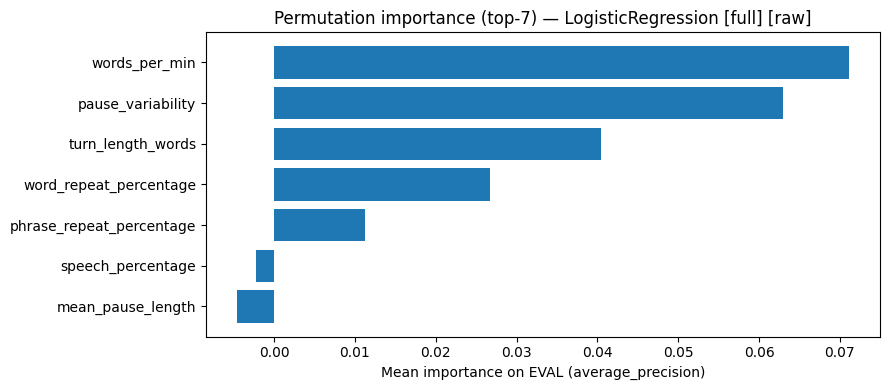


=== LogisticRegression [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Selected cols: ['turn_length_words', 'words_per_min', 'pause_variability', 'phrase_repeat_percentage', 'speech_percentage']
Train+Dev CV PR AUC: 0.4049014485475473 +/- 0.09717566210703246

Classification report:
               precision    recall  f1-score   support

           0      0.800     0.615     0.696        39
           1      0.423     0.647     0.512        17

    accuracy                          0.625        56
   macro avg      0.612     0.631     0.604        56
weighted avg      0.686     0.625     0.640        56

Confusion matrix:
 [[24 15]
 [ 6 11]]

[LogisticRegression [selected(top=5,corr<0.9)]] Top-5 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
           words_per_min         0.063519        0.061554
       pause_variability         0.050061       

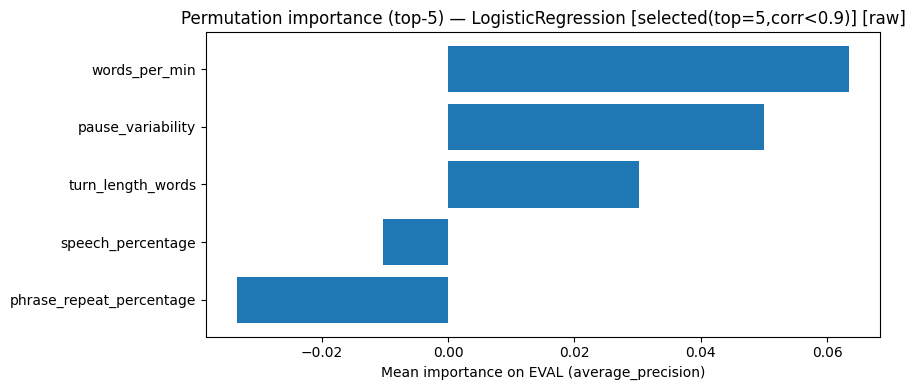


=== SVM [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Best CV score: 0.4037 Best params: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Train+Dev CV PR AUC: 0.4036641223035488 +/- 0.11050081783302959

Classification report:
               precision    recall  f1-score   support

           0      0.800     0.513     0.625        39
           1      0.387     0.706     0.500        17

    accuracy                          0.571        56
   macro avg      0.594     0.609     0.562        56
weighted avg      0.675     0.571     0.587        56

Confusion matrix:
 [[20 19]
 [ 5 12]]

[SVM [full_tuned]] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
           words_per_min         0.054204        0.052616
       turn_length_words         0.032198        0.063380
       speech_percentage         0.017567        0.029268
  word_repeat_p

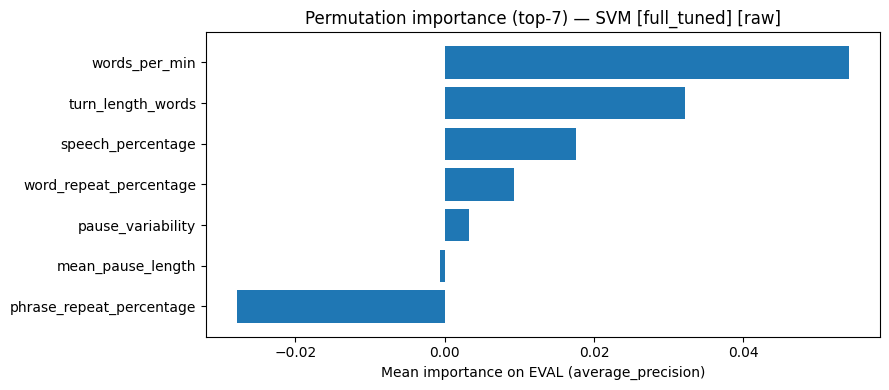


=== SVM [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Selected cols: ['turn_length_words', 'pause_variability', 'word_repeat_percentage', 'phrase_repeat_percentage', 'words_per_min']
Best CV score: 0.3957 Best params: {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Train+Dev CV PR AUC: 0.39566234664809463 +/- 0.13594008273099353

Classification report:
               precision    recall  f1-score   support

           0      0.741     0.513     0.606        39
           1      0.345     0.588     0.435        17

    accuracy                          0.536        56
   macro avg      0.543     0.551     0.520        56
weighted avg      0.621     0.536     0.554        56

Confusion matrix:
 [[20 19]
 [ 7 10]]

[SVM [selected_tuned]] Top-5 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
phrase_repeat_percentage        -0.031216        0.04384

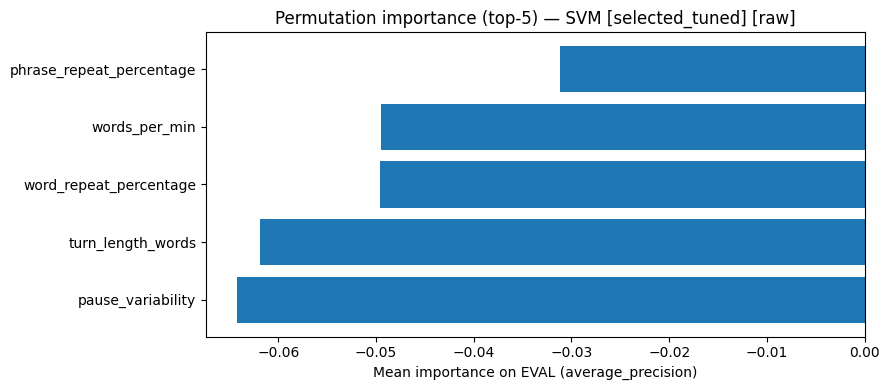


=== SGDClassifier(log_loss) [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Train+Dev CV PR AUC: 0.31088258002768693 +/- 0.06935671559836594

Classification report:
               precision    recall  f1-score   support

           0      0.722     0.333     0.456        39
           1      0.316     0.706     0.436        17

    accuracy                          0.446        56
   macro avg      0.519     0.520     0.446        56
weighted avg      0.599     0.446     0.450        56

Confusion matrix:
 [[13 26]
 [ 5 12]]

[SGDClassifier(log_loss) [full]] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
       turn_length_words         0.032696        0.042077
           words_per_min         0.028380        0.032546
       mean_pause_length        -0.001962        0.008686
       pause_variability        -0.015674        0.013189
phrase_repeat_percentage   

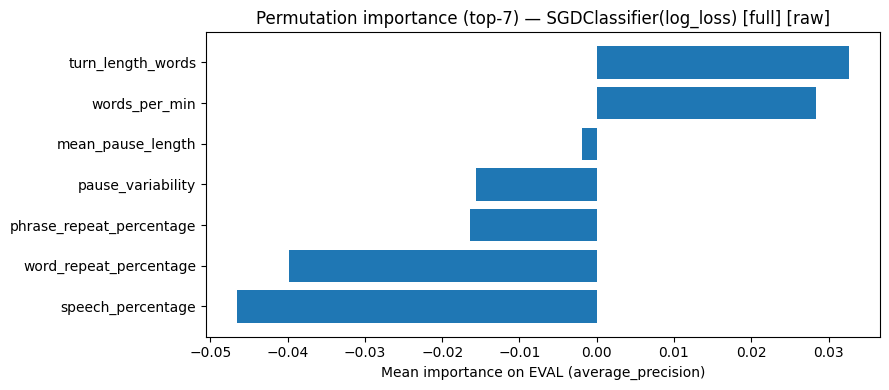


=== SGDClassifier(log_loss) [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Selected cols: ['words_per_min', 'turn_length_words', 'pause_variability', 'word_repeat_percentage', 'phrase_repeat_percentage']
Train+Dev CV PR AUC: 0.3676866868121267 +/- 0.09004924985510414

Classification report:
               precision    recall  f1-score   support

           0      0.636     0.179     0.280        39
           1      0.289     0.765     0.419        17

    accuracy                          0.357        56
   macro avg      0.463     0.472     0.350        56
weighted avg      0.531     0.357     0.322        56

Confusion matrix:
 [[ 7 32]
 [ 4 13]]

[SGDClassifier(log_loss) [selected(top=5,corr<0.9)]] Top-5 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
       turn_length_words         0.042638        0.025065
           words_per_min         

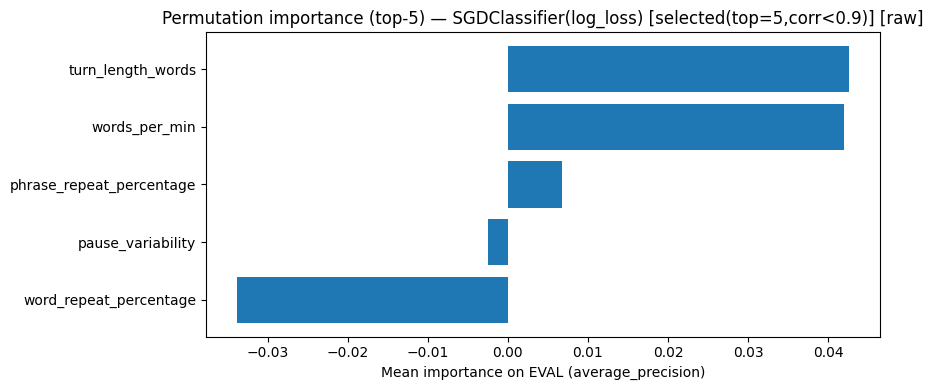

[WARN] DecisionTree[full]: very few unique predicted probabilities (5).

=== DecisionTree [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Best CV score: 0.3161 Best params: {'clf__max_depth': 3, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
Train+Dev CV PR AUC: 0.31606343667423525 +/- 0.061226345932925114

Classification report:
               precision    recall  f1-score   support

           0      0.750     0.692     0.720        39
           1      0.400     0.471     0.432        17

    accuracy                          0.625        56
   macro avg      0.575     0.581     0.576        56
weighted avg      0.644     0.625     0.633        56

Confusion matrix:
 [[27 12]
 [ 9  8]]

[DecisionTree [full_tuned]] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
           words_per_min         0.041960        0.027723
       pause_variability

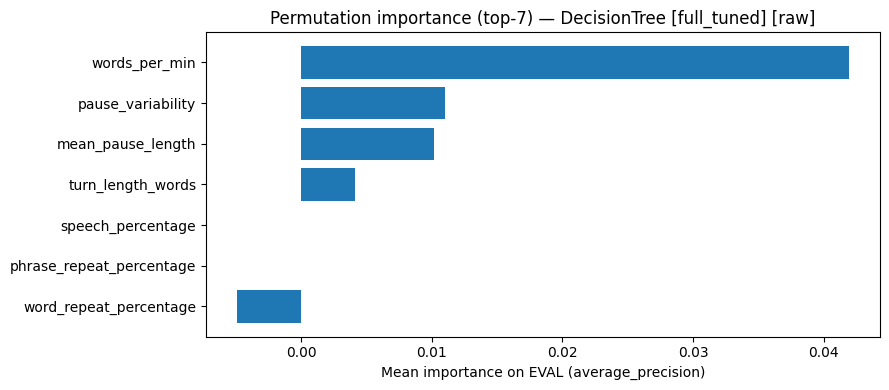


=== DecisionTree [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Selected cols: ['turn_length_words', 'words_per_min', 'pause_variability', 'phrase_repeat_percentage', 'word_repeat_percentage']
Best CV score: 0.3556 Best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10}
Train+Dev CV PR AUC: 0.35555060290586604 +/- 0.09367821504650031

Classification report:
               precision    recall  f1-score   support

           0      0.676     0.641     0.658        39
           1      0.263     0.294     0.278        17

    accuracy                          0.536        56
   macro avg      0.469     0.468     0.468        56
weighted avg      0.550     0.536     0.543        56

Confusion matrix:
 [[25 14]
 [12  5]]

[DecisionTree [selected_tuned]] Top-5 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
phrase_repeat_per

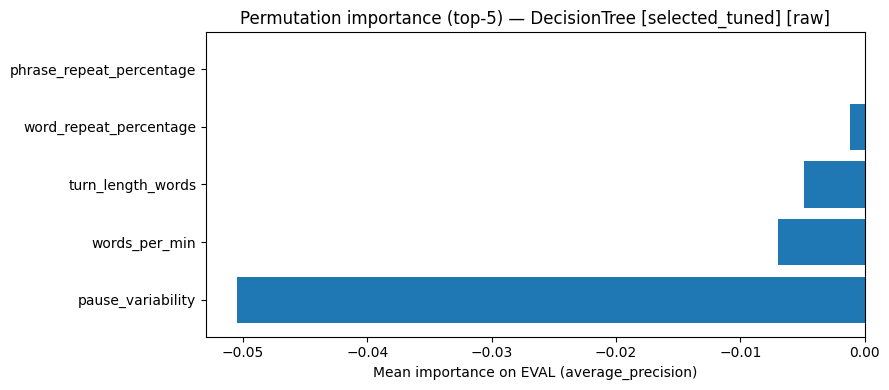


=== RandomForest [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Best CV score: 0.3797 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 500}
Train+Dev CV PR AUC: 0.379654801410927 +/- 0.1347451238292325

Classification report:
               precision    recall  f1-score   support

           0      0.705     0.795     0.747        39
           1      0.333     0.235     0.276        17

    accuracy                          0.625        56
   macro avg      0.519     0.515     0.511        56
weighted avg      0.592     0.625     0.604        56

Confusion matrix:
 [[31  8]
 [13  4]]

[RandomForest [full_tuned]] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
       turn_length_words        -0.000434        0.032850
           words_per_

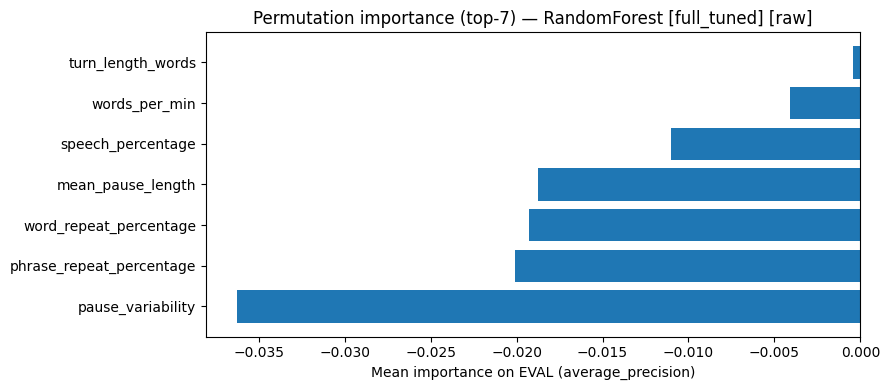


=== RandomForest [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Selected cols: ['turn_length_words', 'pause_variability', 'word_repeat_percentage', 'words_per_min', 'speech_percentage']
Best CV score: 0.3528 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2, 'clf__n_estimators': 500}
Train+Dev CV PR AUC: 0.35284632882650896 +/- 0.08636090129357868

Classification report:
               precision    recall  f1-score   support

           0      0.756     0.795     0.775        39
           1      0.467     0.412     0.438        17

    accuracy                          0.679        56
   macro avg      0.611     0.603     0.606        56
weighted avg      0.668     0.679     0.673        56

Confusion matrix:
 [[31  8]
 [10  7]]

[RandomForest [selected_tuned]] Top-5 permutation importances (average_precision, raw):
    

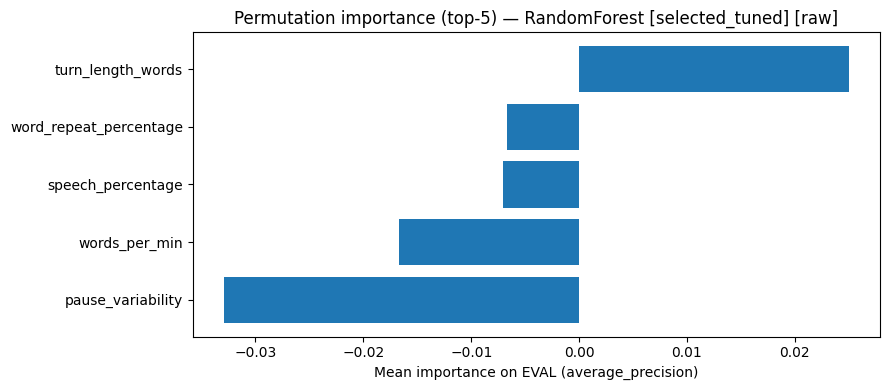


=== XGBoost [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Best CV score: 0.3633 Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__min_child_weight': 5, 'clf__n_estimators': 200, 'clf__reg_lambda': 5.0, 'clf__subsample': 1.0}
Train+Dev CV PR AUC: 0.3633455605053368 +/- 0.09278938585396394

Classification report:
               precision    recall  f1-score   support

           0      0.731     0.487     0.585        39
           1      0.333     0.588     0.426        17

    accuracy                          0.518        56
   macro avg      0.532     0.538     0.505        56
weighted avg      0.610     0.518     0.536        56

Confusion matrix:
 [[19 20]
 [ 7 10]]

[XGBoost [full_tuned]] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
           words_per_min         0.012262        0.036111
      

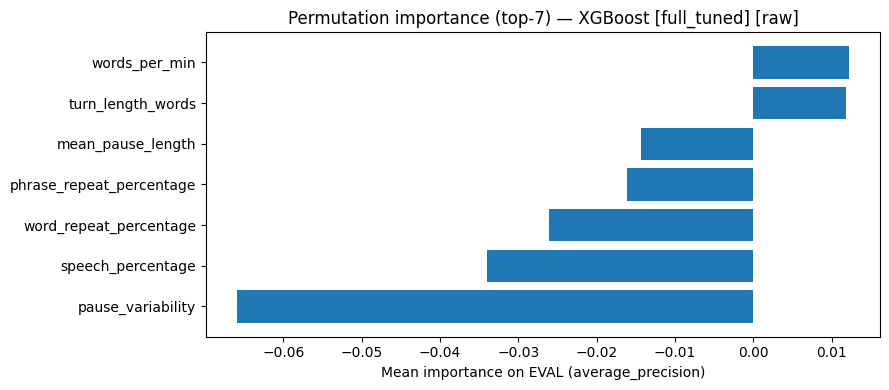


=== XGBoost [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_eng_small_test3.csv) ===
Selected cols: ['turn_length_words', 'pause_variability', 'words_per_min', 'speech_percentage', 'phrase_repeat_percentage']
Best CV score: 0.3686 Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__min_child_weight': 1, 'clf__n_estimators': 200, 'clf__reg_lambda': 5.0, 'clf__subsample': 0.8}
Train+Dev CV PR AUC: 0.36858535701286205 +/- 0.08203374814972175

Classification report:
               precision    recall  f1-score   support

           0      0.759     0.564     0.647        39
           1      0.370     0.588     0.455        17

    accuracy                          0.571        56
   macro avg      0.564     0.576     0.551        56
weighted avg      0.641     0.571     0.589        56

Confusion matrix:
 [[22 17]
 [ 7 10]]

[XGBoost [selected_tuned]] Top-5 permutation importances (average_precis

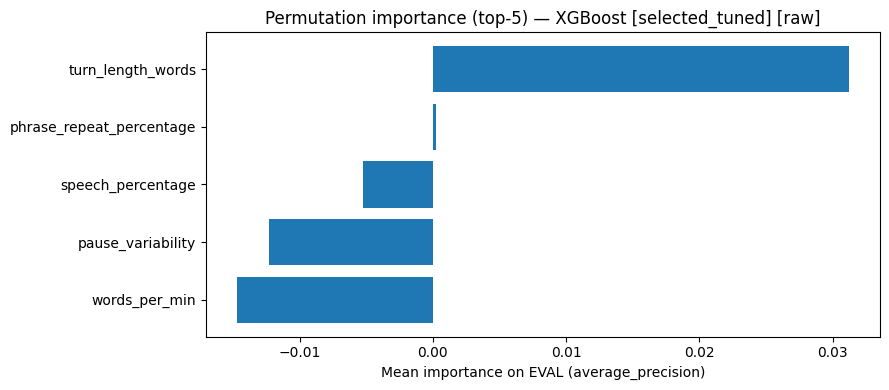


=== Summary metrics on TEST (tuned by PR AUC) ===
          target                   model                  variant  tuned  cv_best_score  cv_pr_auc_mean  cv_pr_auc_std                                                                                                                                                                          best_params  n_train  n_test  n_features_raw  n_features_selected  accuracy  f1_macro  f1_lo  f1_hi  balanced_acc  roc_auc  auc_lo  auc_hi  pr_auc  brier                                                                                     selected_cols
Depression_label      LogisticRegression                     full  False            NaN          0.3773         0.0968                                                                                                                                                                                           219      56               7                  NaN    0.6250    0.6036 0.4759 0.7278        0.6312   0.627

In [4]:
res_b0_ptsd = run_models_pipeline_more_models_tuned_prauc(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_{LANGUAGE}_small_test{ITERATION}.csv",
    target_col="Depression_label",
    importance_top_k=5,
)


In [5]:
res_b0_ptsd

,target,model,variant,tuned,cv_best_score,cv_pr_auc_mean,cv_pr_auc_std,best_params,n_train,n_test,...,f1_macro,f1_lo,f1_hi,balanced_acc,roc_auc,auc_lo,auc_hi,pr_auc,brier,selected_cols
0,Depression_label,LogisticRegression,full,False,NaN,0.377291,0.096849,,219,56,...,0.603640,0.475886,0.727778,0.631222,0.627451,0.452489,0.788876,0.458127,0.246292,
1,Depression_label,LogisticRegression,"selected(top=5,corr<0.9)",False,NaN,0.404901,0.097176,,219,56,...,0.603640,0.475936,0.727778,0.631222,0.628959,0.452489,0.787330,0.453076,0.243284,"turn_length_words,words_per_min,pause_variabil..."
2,Depression_label,SVM,full_tuned,True,0.403664,0.403664,0.110501,"{'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__k...",219,56,...,0.562500,0.437642,0.684245,0.609351,0.631976,0.452489,0.794872,0.455851,0.209534,
3,Depression_label,SVM,selected_tuned,True,0.395662,0.395662,0.135940,"{'clf__C': 1, 'clf__gamma': 'scale', 'clf__ker...",219,56,...,0.520422,0.392082,0.650000,0.550528,0.479638,0.315158,0.651621,0.320523,0.218588,"turn_length_words,pause_variability,word_repea..."
4,Depression_label,SGDClassifier(log_loss),full,False,NaN,0.310883,0.069357,,219,56,...,0.446252,0.333847,0.569231,0.519608,0.514329,0.351433,0.678733,0.353856,0.520731,
5,Depression_label,SGDClassifier(log_loss),"selected(top=5,corr<0.9)",False,NaN,0.367687,0.090049,,219,56,...,0.349677,0.241290,0.461538,0.472097,0.559578,0.384578,0.726998,0.365102,0.558158,"words_per_min,turn_length_words,pause_variabil..."
6,Depression_label,DecisionTree,full_tuned,True,0.316063,0.316063,0.061226,"{'clf__max_depth': 3, 'clf__min_samples_leaf':...",219,56,...,0.576216,0.442116,0.704953,0.581448,0.568627,0.407240,0.716459,0.351651,0.298036,
7,Depression_label,DecisionTree,selected_tuned,True,0.355551,0.355551,0.093678,"{'clf__max_depth': 5, 'clf__min_samples_leaf':...",219,56,...,0.467836,0.339387,0.591868,0.467572,0.521116,0.366516,0.671248,0.325704,0.337482,"turn_length_words,words_per_min,pause_variabil..."
8,Depression_label,RandomForest,full_tuned,True,0.379655,0.379655,0.134745,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.511425,0.380952,0.650000,0.515083,0.505279,0.321267,0.680279,0.330425,0.256010,
9,Depression_label,RandomForest,selected_tuned,True,0.352846,0.352846,0.086361,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.606250,0.455545,0.744080,0.603318,0.580694,0.405732,0.746644,0.374684,0.246112,"turn_length_words,pause_variability,word_repea..."



[INFO] target_col = Depression_label
[INFO] standardized drop_cols (8): ['Depression_label', 'Depression_severity', 'PTSD_label', 'PTSD_severity', 'Participant', 'age', 'gender', 'split']
[INFO] X_train shape: (219, 13) | X_test shape: (56, 13)
[INFO] class counts train: [170  49] | test: [39 17]

=== LogisticRegression [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Train+Dev CV PR AUC: 0.3707798096281004 +/- 0.08056800727757761

Classification report:
               precision    recall  f1-score   support

           0      0.708     0.436     0.540        39
           1      0.312     0.588     0.408        17

    accuracy                          0.482        56
   macro avg      0.510     0.512     0.474        56
weighted avg      0.588     0.482     0.500        56

Confusion matrix:
 [[17 22]
 [ 7 10]]

[LogisticRegression [full]] Top-10 permutation importances (average_precision, raw):
                             

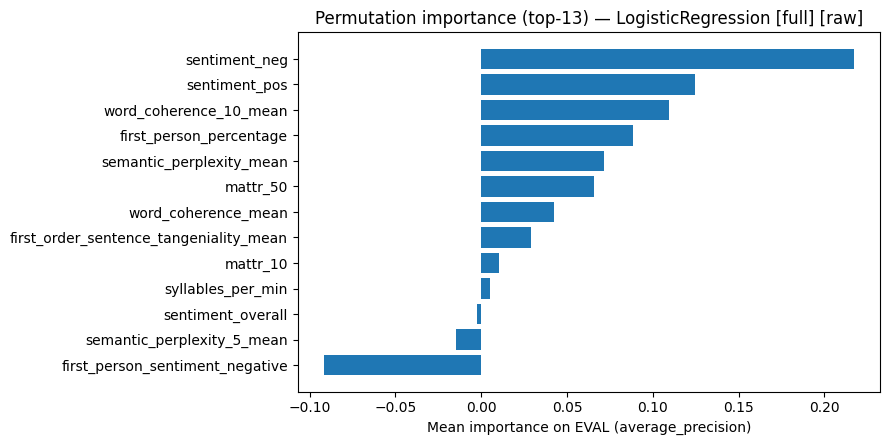


=== LogisticRegression [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Selected cols: ['sentiment_neg', 'sentiment_pos', 'syllables_per_min', 'sentiment_overall', 'first_person_percentage']
Train+Dev CV PR AUC: 0.40418038212807234 +/- 0.096024788673688

Classification report:
               precision    recall  f1-score   support

           0      0.783     0.462     0.581        39
           1      0.364     0.706     0.480        17

    accuracy                          0.536        56
   macro avg      0.573     0.584     0.530        56
weighted avg      0.655     0.536     0.550        56

Confusion matrix:
 [[18 21]
 [ 5 12]]

[LogisticRegression [selected(top=5,corr<0.9)]] Top-5 permutation importances (average_precision, raw):
                feature  importance_mean  importance_std
          sentiment_neg         0.168880        0.024746
          sentiment_pos         0.104601        0.042891


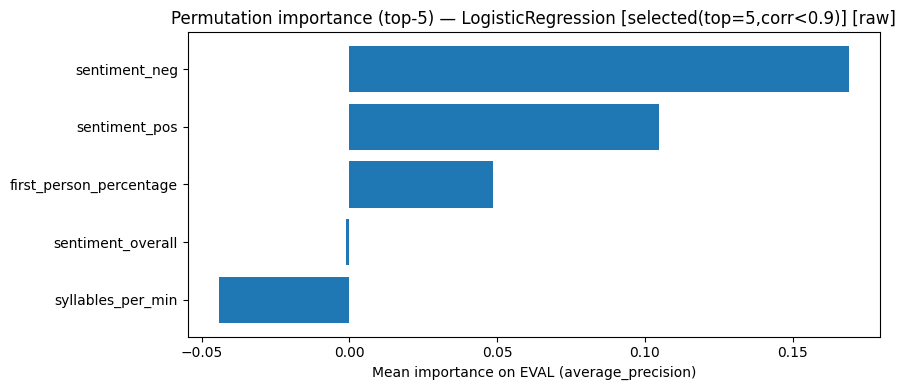


=== SVM [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Best CV score: 0.3972 Best params: {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Train+Dev CV PR AUC: 0.39715070157812826 +/- 0.040781856894476165

Classification report:
               precision    recall  f1-score   support

           0      0.686     0.615     0.649        39
           1      0.286     0.353     0.316        17

    accuracy                          0.536        56
   macro avg      0.486     0.484     0.482        56
weighted avg      0.564     0.536     0.548        56

Confusion matrix:
 [[24 15]
 [11  6]]

[SVM [full_tuned]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
                              mattr_50         0.031446        0.017004
                     syllables_per_min         0.024462        0.020944
first_order_sentence_tangeniality_

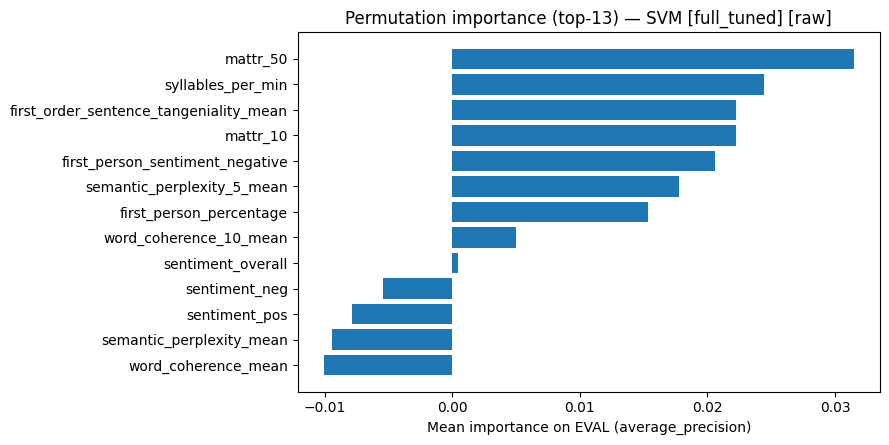


=== SVM [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Selected cols: ['sentiment_pos', 'syllables_per_min', 'semantic_perplexity_5_mean', 'first_person_percentage', 'sentiment_neg']
Best CV score: 0.3691 Best params: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Train+Dev CV PR AUC: 0.3690994291805968 +/- 0.0769258701233005

Classification report:
               precision    recall  f1-score   support

           0      0.800     0.410     0.542        39
           1      0.361     0.765     0.491        17

    accuracy                          0.518        56
   macro avg      0.581     0.587     0.516        56
weighted avg      0.667     0.518     0.527        56

Confusion matrix:
 [[16 23]
 [ 4 13]]

[SVM [selected_tuned]] Top-5 permutation importances (average_precision, raw):
                   feature  importance_mean  importance_std
             sentiment_neg         0.129951        0.

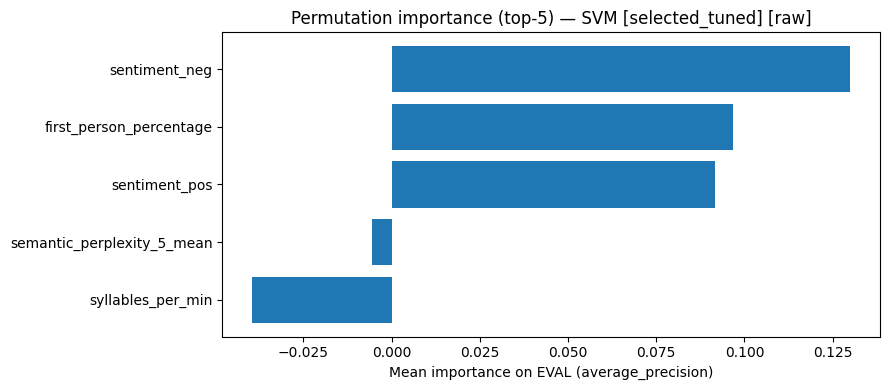


=== SGDClassifier(log_loss) [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Train+Dev CV PR AUC: 0.37419673094137923 +/- 0.04971453475112025

Classification report:
               precision    recall  f1-score   support

           0      0.684     0.333     0.448        39
           1      0.297     0.647     0.407        17

    accuracy                          0.429        56
   macro avg      0.491     0.490     0.428        56
weighted avg      0.567     0.429     0.436        56

Confusion matrix:
 [[13 26]
 [ 6 11]]

[SGDClassifier(log_loss) [full]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
                         sentiment_neg         0.052280        0.008802
                     sentiment_overall         0.009527        0.006853
               first_person_percentage         0.007205        0.013160
                word_coherenc

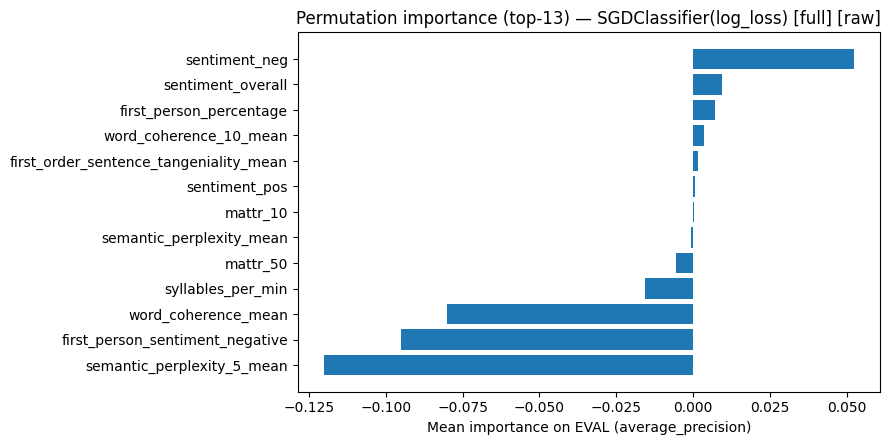


=== SGDClassifier(log_loss) [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Selected cols: ['first_person_percentage', 'syllables_per_min', 'sentiment_neg', 'sentiment_overall', 'word_coherence_mean']
Train+Dev CV PR AUC: 0.3691337902746441 +/- 0.07744914782197611

Classification report:
               precision    recall  f1-score   support

           0      0.714     0.385     0.500        39
           1      0.314     0.647     0.423        17

    accuracy                          0.464        56
   macro avg      0.514     0.516     0.462        56
weighted avg      0.593     0.464     0.477        56

Confusion matrix:
 [[15 24]
 [ 6 11]]

[SGDClassifier(log_loss) [selected(top=5,corr<0.9)]] Top-5 permutation importances (average_precision, raw):
                feature  importance_mean  importance_std
      sentiment_overall         0.043814        0.022027
          sentiment_neg         0.000536

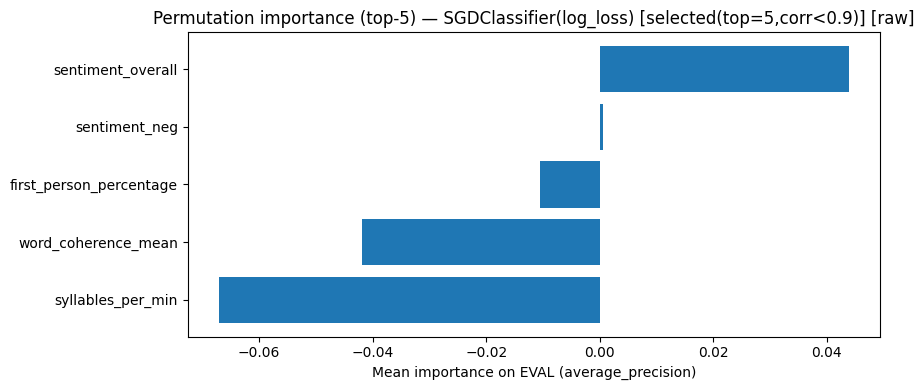


=== DecisionTree [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Best CV score: 0.3198 Best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5}
Train+Dev CV PR AUC: 0.31983541180488406 +/- 0.10315826708057131

Classification report:
               precision    recall  f1-score   support

           0      0.700     0.359     0.475        39
           1      0.306     0.647     0.415        17

    accuracy                          0.446        56
   macro avg      0.503     0.503     0.445        56
weighted avg      0.580     0.446     0.457        56

Confusion matrix:
 [[14 25]
 [ 6 11]]

[DecisionTree [full_tuned]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
               first_person_percentage         0.007679        0.002779
                     sentiment_overall         0.000000        0.0000

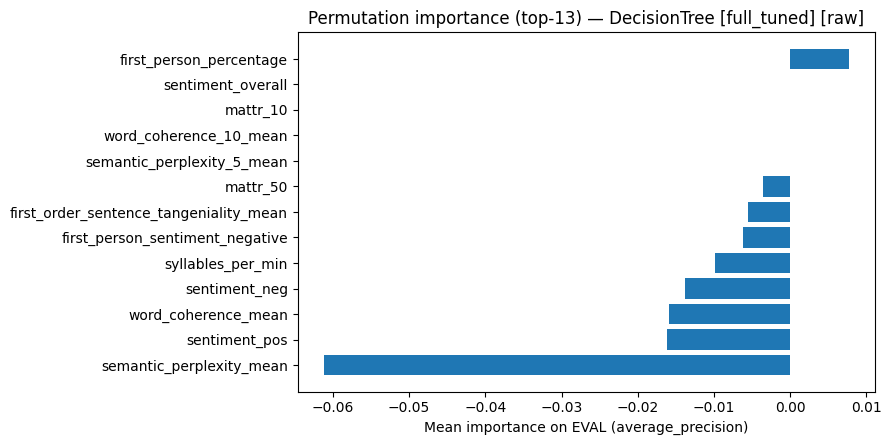


=== DecisionTree [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Selected cols: ['mattr_10', 'sentiment_pos', 'first_person_percentage', 'sentiment_overall', 'semantic_perplexity_mean']
Best CV score: 0.3868 Best params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2}
Train+Dev CV PR AUC: 0.3868432467618514 +/- 0.09731539138063623

Classification report:
               precision    recall  f1-score   support

           0      0.735     0.641     0.685        39
           1      0.364     0.471     0.410        17

    accuracy                          0.589        56
   macro avg      0.549     0.556     0.548        56
weighted avg      0.622     0.589     0.602        56

Confusion matrix:
 [[25 14]
 [ 9  8]]

[DecisionTree [selected_tuned]] Top-5 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
 first_person_percentage   

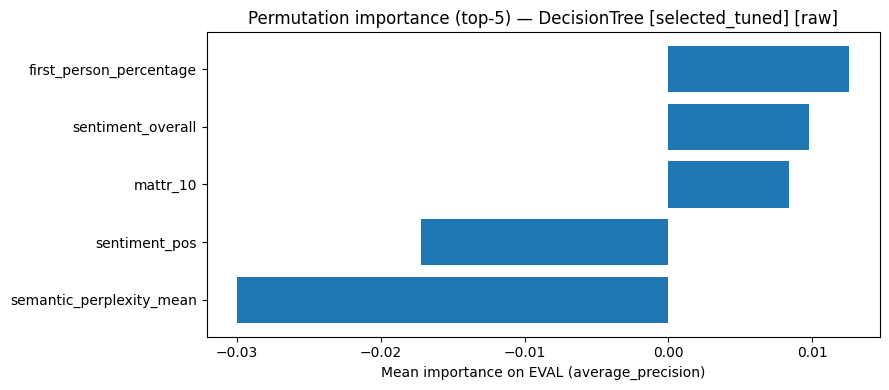


=== RandomForest [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Best CV score: 0.3804 Best params: {'clf__bootstrap': True, 'clf__max_depth': None, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Train+Dev CV PR AUC: 0.3803814670650344 +/- 0.10156049904901081

Classification report:
               precision    recall  f1-score   support

           0      0.698     0.949     0.804        39
           1      0.333     0.059     0.100        17

    accuracy                          0.679        56
   macro avg      0.516     0.504     0.452        56
weighted avg      0.587     0.679     0.591        56

Confusion matrix:
 [[37  2]
 [16  1]]

[RandomForest [full_tuned]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
first_order_sentence_tangeniality_mean         0.035699        

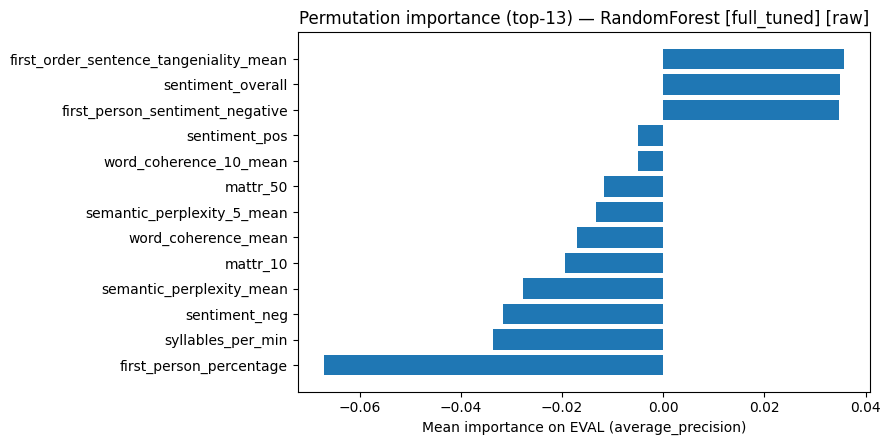


=== RandomForest [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Selected cols: ['sentiment_pos', 'first_person_percentage', 'sentiment_overall', 'first_order_sentence_tangeniality_mean', 'syllables_per_min']
Best CV score: 0.3902 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Train+Dev CV PR AUC: 0.390178342848721 +/- 0.04508682286452806

Classification report:
               precision    recall  f1-score   support

           0      0.721     0.795     0.756        39
           1      0.385     0.294     0.333        17

    accuracy                          0.643        56
   macro avg      0.553     0.544     0.545        56
weighted avg      0.619     0.643     0.628        56

Confusion matrix:
 [[31  8]
 [12  5]]

[RandomForest [selected_tuned]] Top-5 permutation importances (average_pr

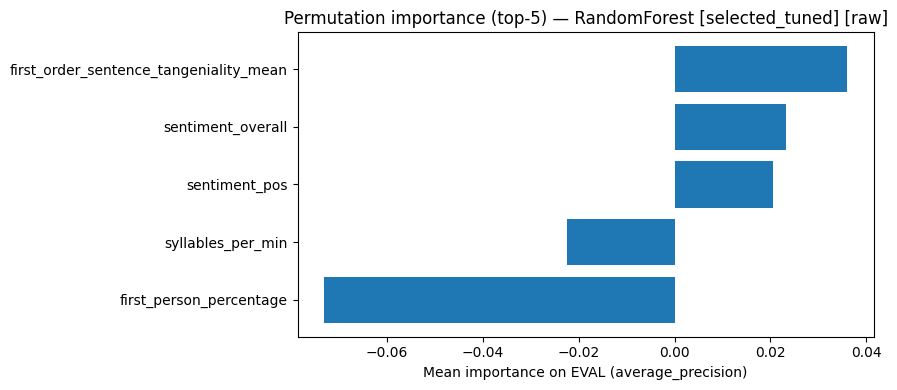


=== XGBoost [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Best CV score: 0.4065 Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__min_child_weight': 5, 'clf__n_estimators': 200, 'clf__reg_lambda': 1.0, 'clf__subsample': 1.0}
Train+Dev CV PR AUC: 0.40652887174598806 +/- 0.09737017853655422

Classification report:
               precision    recall  f1-score   support

           0      0.696     0.821     0.753        39
           1      0.300     0.176     0.222        17

    accuracy                          0.625        56
   macro avg      0.498     0.498     0.488        56
weighted avg      0.576     0.625     0.592        56

Confusion matrix:
 [[32  7]
 [14  3]]

[XGBoost [full_tuned]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
                         sentiment_pos         0.0

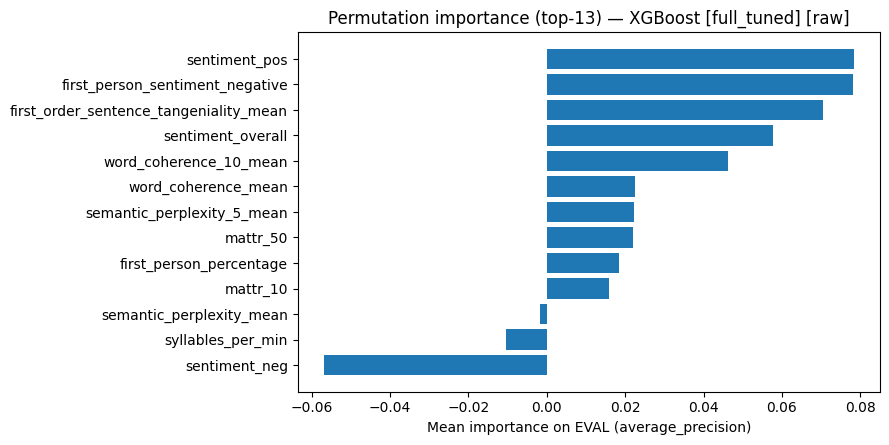


=== XGBoost [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_eng_small_test3.csv) ===
Selected cols: ['sentiment_pos', 'word_coherence_mean', 'first_person_percentage', 'semantic_perplexity_mean', 'sentiment_overall']
Best CV score: 0.455 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.03, 'clf__max_depth': 10, 'clf__min_child_weight': 1, 'clf__n_estimators': 500, 'clf__reg_lambda': 5.0, 'clf__subsample': 1.0}
Train+Dev CV PR AUC: 0.4549955507759999 +/- 0.055671361907730275

Classification report:
               precision    recall  f1-score   support

           0      0.721     0.795     0.756        39
           1      0.385     0.294     0.333        17

    accuracy                          0.643        56
   macro avg      0.553     0.544     0.545        56
weighted avg      0.619     0.643     0.628        56

Confusion matrix:
 [[31  8]
 [12  5]]

[XGBoost [selected_tuned]] Top-5 permutation importances (average

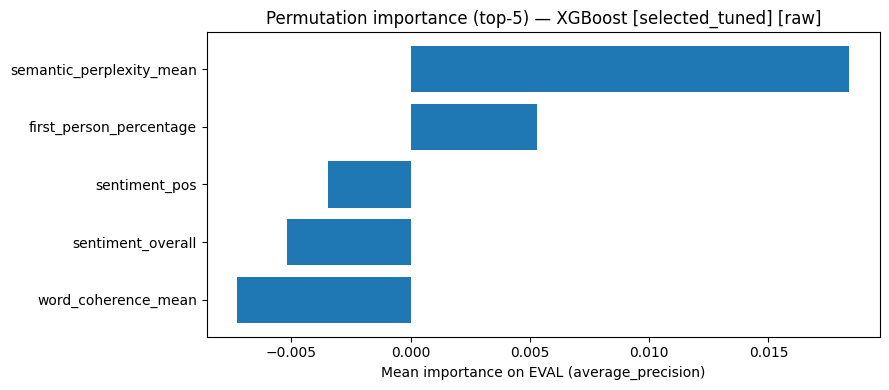


=== Summary metrics on TEST (tuned by PR AUC) ===
          target                   model                  variant  tuned  cv_best_score  cv_pr_auc_mean  cv_pr_auc_std                                                                                                                                                                           best_params  n_train  n_test  n_features_raw  n_features_selected  accuracy  f1_macro  f1_lo  f1_hi  balanced_acc  roc_auc  auc_lo  auc_hi  pr_auc  brier                                                                                                    selected_cols
Depression_label      LogisticRegression                     full  False            NaN          0.3708         0.0806                                                                                                                                                                                            219      56              13                  NaN    0.4821    0.4739 0.3497 0.5990     

In [6]:
res_l_ptsd = run_models_pipeline_more_models_tuned_prauc(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_{LANGUAGE}_small_test{ITERATION}.csv",
    target_col="Depression_label",
    importance_top_k=5,
)

In [7]:
res_l_ptsd

,target,model,variant,tuned,cv_best_score,cv_pr_auc_mean,cv_pr_auc_std,best_params,n_train,n_test,...,f1_macro,f1_lo,f1_hi,balanced_acc,roc_auc,auc_lo,auc_hi,pr_auc,brier,selected_cols
0,Depression_label,LogisticRegression,full,False,NaN,0.370780,0.080568,,219,56,...,0.473923,0.349677,0.598958,0.512066,0.553544,0.366516,0.737557,0.465930,0.271311,
1,Depression_label,LogisticRegression,"selected(top=5,corr<0.9)",False,NaN,0.404180,0.096025,,219,56,...,0.530323,0.408942,0.647213,0.583710,0.662142,0.490158,0.826546,0.617147,0.255018,"sentiment_neg,sentiment_pos,syllables_per_min,..."
2,Depression_label,SVM,full_tuned,True,0.397151,0.397151,0.040782,"{'clf__C': 1, 'clf__gamma': 'scale', 'clf__ker...",219,56,...,0.482219,0.355844,0.616577,0.484163,0.512821,0.354449,0.683258,0.360964,0.219106,
3,Depression_label,SVM,selected_tuned,True,0.369099,0.369099,0.076926,"{'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__k...",219,56,...,0.516469,0.392857,0.638710,0.587481,0.636501,0.461538,0.805430,0.582571,0.197604,"sentiment_pos,syllables_per_min,semantic_perpl..."
4,Depression_label,SGDClassifier(log_loss),full,False,NaN,0.374197,0.049715,,219,56,...,0.427842,0.303305,0.549984,0.490196,0.538462,0.384615,0.684766,0.313640,0.523117,
5,Depression_label,SGDClassifier(log_loss),"selected(top=5,corr<0.9)",False,NaN,0.369134,0.077449,,219,56,...,0.461538,0.333976,0.582766,0.515837,0.520362,0.358937,0.678771,0.361655,0.489213,"first_person_percentage,syllables_per_min,sent..."
6,Depression_label,DecisionTree,full_tuned,True,0.319835,0.319835,0.103158,"{'clf__max_depth': 5, 'clf__min_samples_leaf':...",219,56,...,0.444835,0.320562,0.569231,0.503017,0.476621,0.316742,0.636501,0.304886,0.365423,
7,Depression_label,DecisionTree,selected_tuned,True,0.386843,0.386843,0.097315,"{'clf__max_depth': 10, 'clf__min_samples_leaf'...",219,56,...,0.547594,0.414894,0.672965,0.555807,0.542232,0.395173,0.697587,0.340157,0.347346,"mattr_10,sentiment_pos,first_person_percentage..."
8,Depression_label,RandomForest,full_tuned,True,0.380381,0.380381,0.101560,"{'clf__bootstrap': True, 'clf__max_depth': Non...",219,56,...,0.452174,0.384615,0.560440,0.503771,0.539970,0.374020,0.710445,0.400042,0.211147,
9,Depression_label,RandomForest,selected_tuned,True,0.390178,0.390178,0.045087,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.544715,0.408122,0.682789,0.544495,0.494721,0.336350,0.668175,0.334003,0.244490,"sentiment_pos,first_person_percentage,sentimen..."



[INFO] target_col = Depression_label
[INFO] standardized drop_cols (8): ['Depression_label', 'Depression_severity', 'PTSD_label', 'PTSD_severity', 'Participant', 'age', 'gender', 'split']
[INFO] X_train shape: (219, 20) | X_test shape: (56, 20)
[INFO] class counts train: [170  49] | test: [39 17]

=== LogisticRegression [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Train+Dev CV PR AUC: 0.42124371958799217 +/- 0.06976171395844831

Classification report:
               precision    recall  f1-score   support

           0      0.735     0.641     0.685        39
           1      0.364     0.471     0.410        17

    accuracy                          0.589        56
   macro avg      0.549     0.556     0.548        56
weighted avg      0.622     0.589     0.602        56

Confusion matrix:
 [[25 14]
 [ 9  8]]

[LogisticRegression [full]] Top-10 permutation importances (average_precision, raw):
                   feature

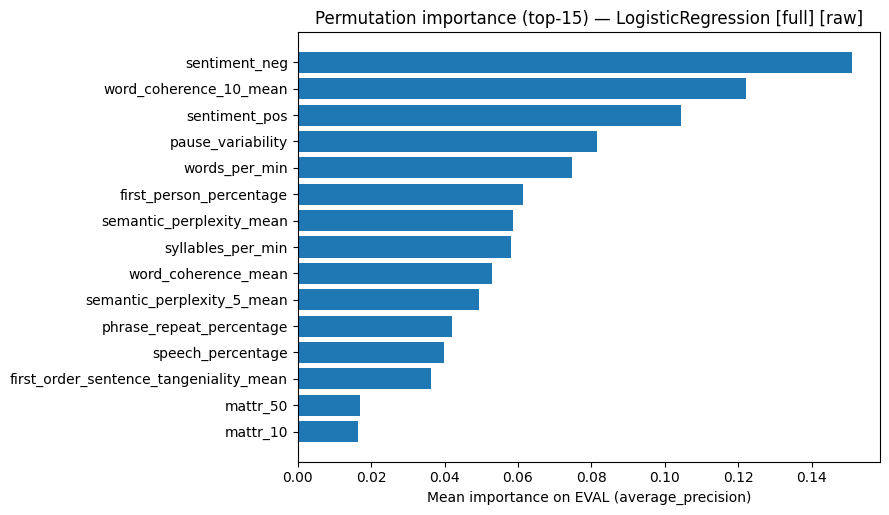


=== LogisticRegression [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Selected cols: ['sentiment_neg', 'pause_variability', 'word_coherence_10_mean', 'sentiment_overall', 'sentiment_pos']
Train+Dev CV PR AUC: 0.4085189751286464 +/- 0.09878242531223205

Classification report:
               precision    recall  f1-score   support

           0      0.800     0.513     0.625        39
           1      0.387     0.706     0.500        17

    accuracy                          0.571        56
   macro avg      0.594     0.609     0.562        56
weighted avg      0.675     0.571     0.587        56

Confusion matrix:
 [[20 19]
 [ 5 12]]

[LogisticRegression [selected(top=5,corr<0.9)]] Top-5 permutation importances (average_precision, raw):
               feature  importance_mean  importance_std
         sentiment_neg         0.343344        0.042227
         sentiment_pos         0.148735        0.070523
 

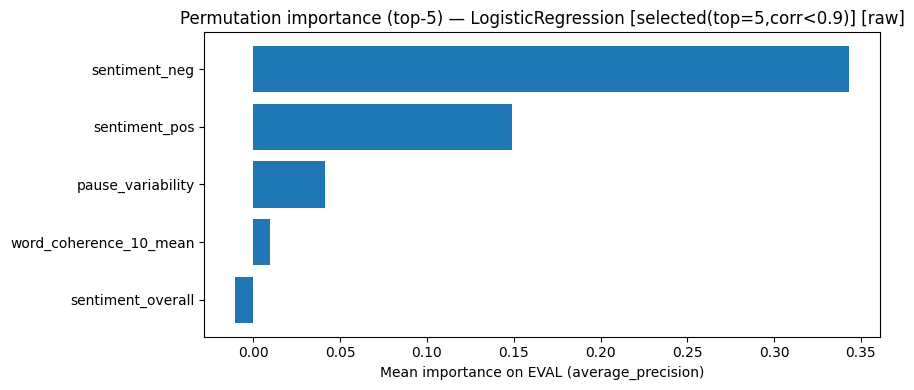


=== SVM [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Best CV score: 0.429 Best params: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Train+Dev CV PR AUC: 0.4290085689849682 +/- 0.057394933918194245

Classification report:
               precision    recall  f1-score   support

           0      0.767     0.846     0.805        39
           1      0.538     0.412     0.467        17

    accuracy                          0.714        56
   macro avg      0.653     0.629     0.636        56
weighted avg      0.698     0.714     0.702        56

Confusion matrix:
 [[33  6]
 [10  7]]

[SVM [full_tuned]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
                         sentiment_neg         0.029454        0.015988
                     sentiment_overall        -0.001084        0.001715
                     syllables_p

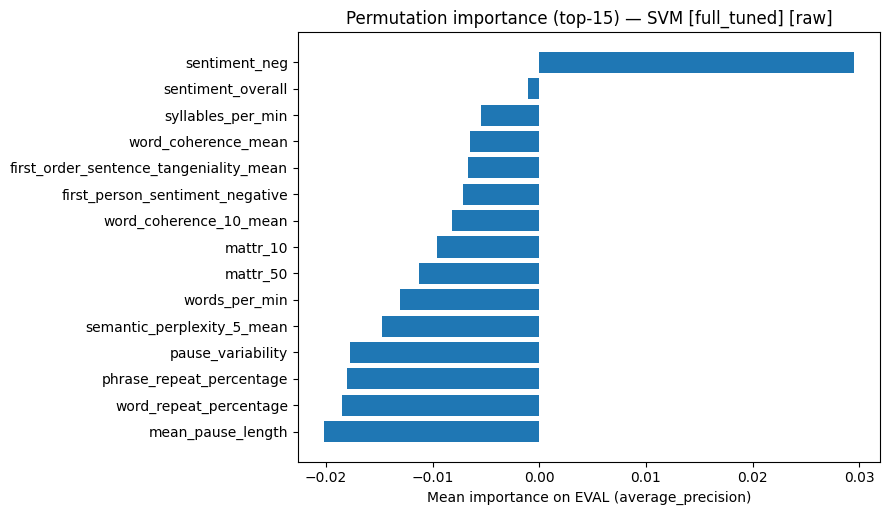


=== SVM [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Selected cols: ['sentiment_pos', 'words_per_min', 'phrase_repeat_percentage', 'first_order_sentence_tangeniality_mean', 'syllables_per_min']
Best CV score: 0.4513 Best params: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Train+Dev CV PR AUC: 0.4513048578771244 +/- 0.05235525156702

Classification report:
               precision    recall  f1-score   support

           0      0.667     0.359     0.467        39
           1      0.286     0.588     0.385        17

    accuracy                          0.429        56
   macro avg      0.476     0.474     0.426        56
weighted avg      0.551     0.429     0.442        56

Confusion matrix:
 [[14 25]
 [ 7 10]]

[SVM [selected_tuned]] Top-5 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
                         sen

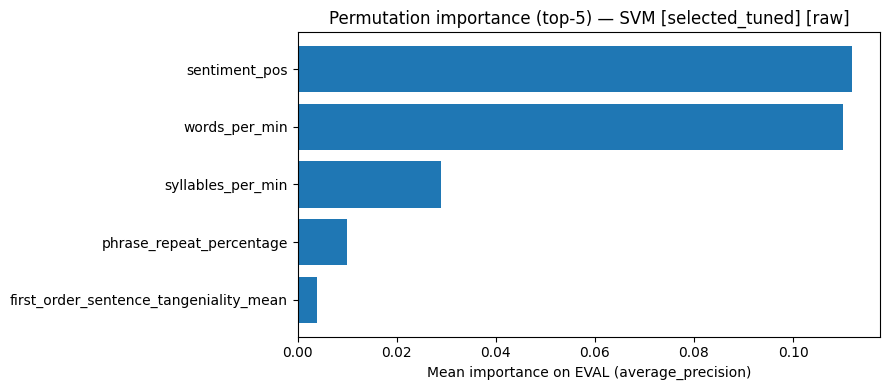


=== SGDClassifier(log_loss) [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Train+Dev CV PR AUC: 0.39693658632081114 +/- 0.0754354803443012

Classification report:
               precision    recall  f1-score   support

           0      0.667     0.564     0.611        39
           1      0.261     0.353     0.300        17

    accuracy                          0.500        56
   macro avg      0.464     0.459     0.456        56
weighted avg      0.543     0.500     0.517        56

Confusion matrix:
 [[22 17]
 [11  6]]

[SGDClassifier(log_loss) [full]] Top-10 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
           sentiment_neg         0.072570        0.011560
           words_per_min         0.032972        0.018600
phrase_repeat_percentage         0.029228        0.018060
       sentiment_overall         0.026952        0.015547
           sentiment_pos  

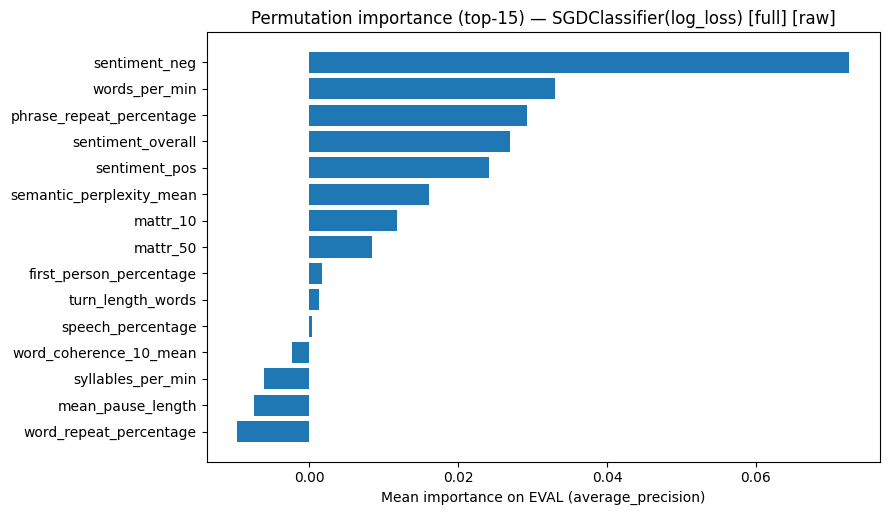


=== SGDClassifier(log_loss) [selected(top=5,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Selected cols: ['pause_variability', 'word_coherence_10_mean', 'sentiment_overall', 'sentiment_neg', 'mattr_50']
Train+Dev CV PR AUC: 0.2998654298532239 +/- 0.10438379651079611

Classification report:
               precision    recall  f1-score   support

           0      0.562     0.231     0.327        39
           1      0.250     0.588     0.351        17

    accuracy                          0.339        56
   macro avg      0.406     0.410     0.339        56
weighted avg      0.468     0.339     0.334        56

Confusion matrix:
 [[ 9 30]
 [ 7 10]]

[SGDClassifier(log_loss) [selected(top=5,corr<0.9)]] Top-5 permutation importances (average_precision, raw):
               feature  importance_mean  importance_std
     sentiment_overall         0.098376        0.050300
word_coherence_10_mean         0.010216        0.016

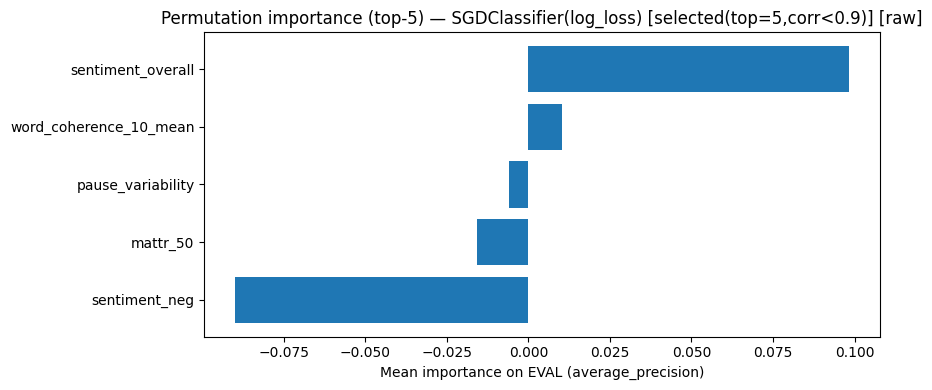


=== DecisionTree [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Best CV score: 0.3499 Best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10}
Train+Dev CV PR AUC: 0.34988895595461944 +/- 0.06850281543145469

Classification report:
               precision    recall  f1-score   support

           0      0.659     0.692     0.675        39
           1      0.200     0.176     0.188        17

    accuracy                          0.536        56
   macro avg      0.429     0.434     0.431        56
weighted avg      0.519     0.536     0.527        56

Confusion matrix:
 [[27 12]
 [14  3]]

[DecisionTree [full_tuned]] Top-10 permutation importances (average_precision, raw):
                        feature  importance_mean  importance_std
              pause_variability         0.003078        0.004376
        first_person_percentage         0.000440        0.015845
              s

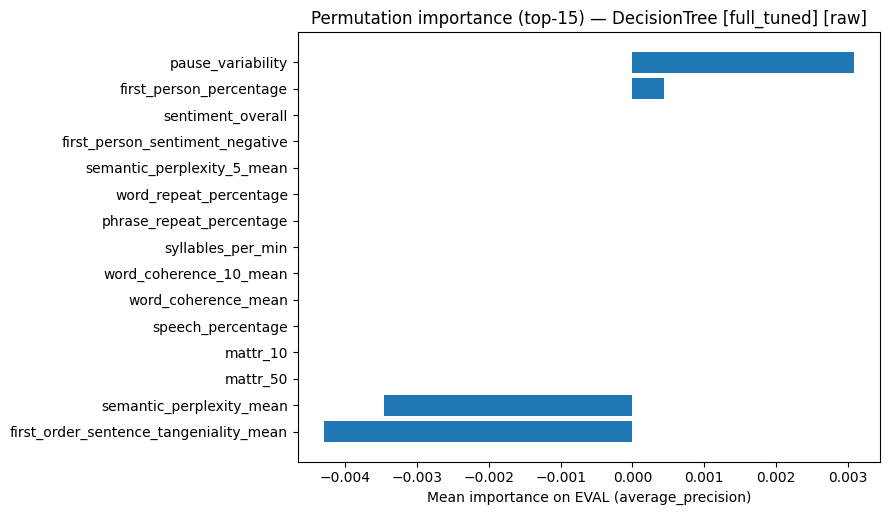


=== DecisionTree [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Selected cols: ['words_per_min', 'pause_variability', 'sentiment_pos', 'speech_percentage', 'semantic_perplexity_mean']
Best CV score: 0.4347 Best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 8, 'clf__min_samples_split': 2}
Train+Dev CV PR AUC: 0.43473239908239913 +/- 0.03811018506888624

Classification report:
               precision    recall  f1-score   support

           0      0.679     0.487     0.567        39
           1      0.286     0.471     0.356        17

    accuracy                          0.482        56
   macro avg      0.482     0.479     0.461        56
weighted avg      0.559     0.482     0.503        56

Confusion matrix:
 [[19 20]
 [ 9  8]]

[DecisionTree [selected_tuned]] Top-5 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
           words_per_min  

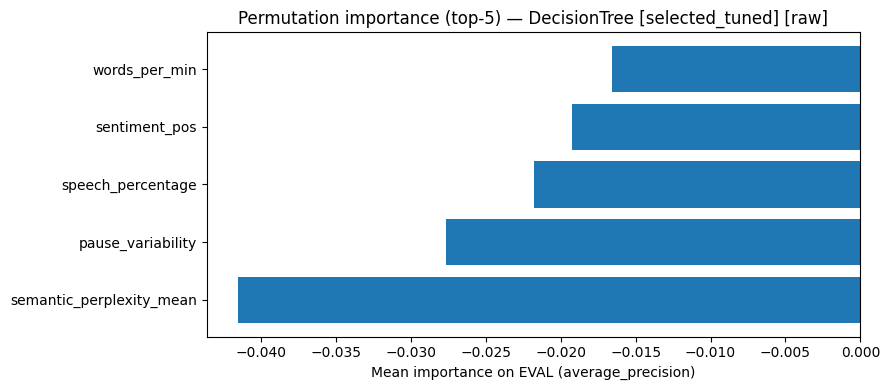


=== RandomForest [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Best CV score: 0.4095 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Train+Dev CV PR AUC: 0.40949224283803753 +/- 0.1113233336985242

Classification report:
               precision    recall  f1-score   support

           0      0.708     0.872     0.782        39
           1      0.375     0.176     0.240        17

    accuracy                          0.661        56
   macro avg      0.542     0.524     0.511        56
weighted avg      0.607     0.661     0.617        56

Confusion matrix:
 [[34  5]
 [14  3]]

[RandomForest [full_tuned]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
first_order_sentence_tangeniality_mean         0.011849      

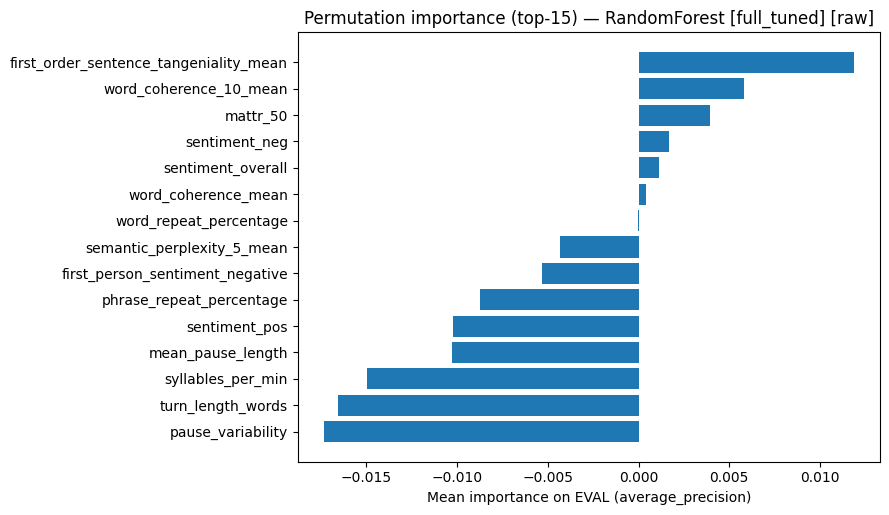


=== RandomForest [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Selected cols: ['sentiment_pos', 'sentiment_overall', 'semantic_perplexity_mean', 'speech_percentage', 'first_person_percentage']
Best CV score: 0.4778 Best params: {'clf__bootstrap': True, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}
Train+Dev CV PR AUC: 0.47779685569362484 +/- 0.04901020439692074

Classification report:
               precision    recall  f1-score   support

           0      0.690     0.744     0.716        39
           1      0.286     0.235     0.258        17

    accuracy                          0.589        56
   macro avg      0.488     0.489     0.487        56
weighted avg      0.568     0.589     0.577        56

Confusion matrix:
 [[29 10]
 [13  4]]

[RandomForest [selected_tuned]] Top-5 permutation importances (average_precisio

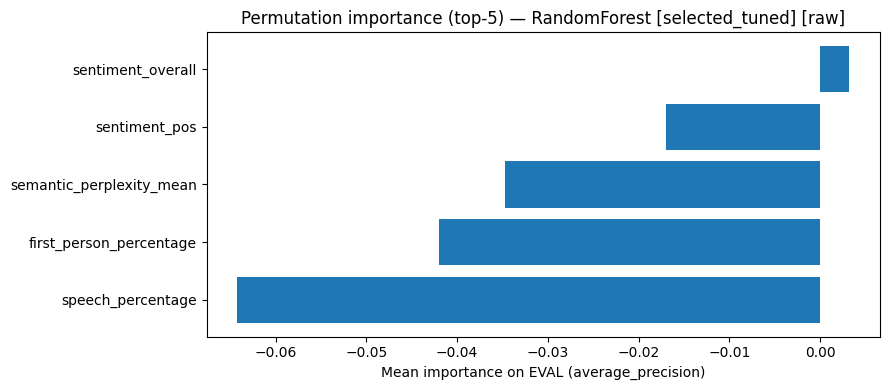


=== XGBoost [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Best CV score: 0.3983 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 10, 'clf__min_child_weight': 1, 'clf__n_estimators': 200, 'clf__reg_lambda': 1.0, 'clf__subsample': 0.8}
Train+Dev CV PR AUC: 0.39829783265411706 +/- 0.08692875842838461

Classification report:
               precision    recall  f1-score   support

           0      0.686     0.897     0.778        39
           1      0.200     0.059     0.091        17

    accuracy                          0.643        56
   macro avg      0.443     0.478     0.434        56
weighted avg      0.539     0.643     0.569        56

Confusion matrix:
 [[35  4]
 [16  1]]

[XGBoost [full_tuned]] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
                     sentiment_overall         

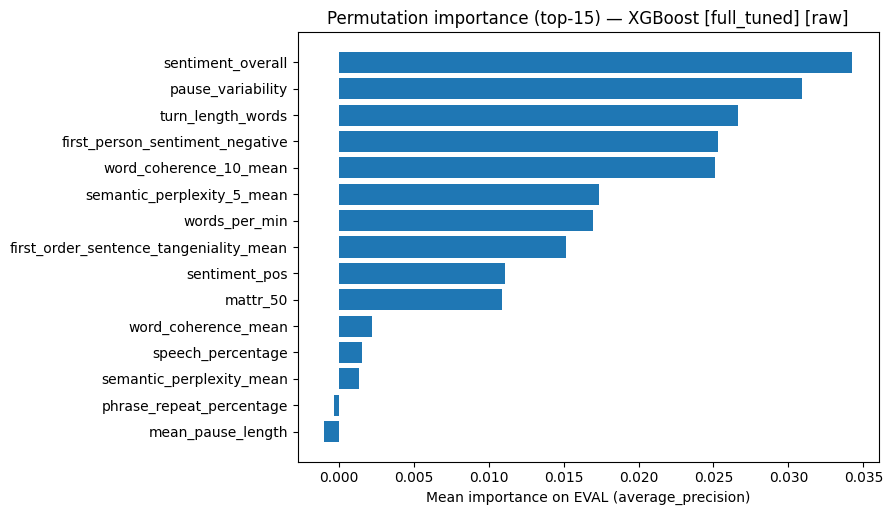


=== XGBoost [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_eng_full3.csv) ===
Selected cols: ['semantic_perplexity_mean', 'sentiment_pos', 'first_person_percentage', 'mattr_50', 'sentiment_overall']
Best CV score: 0.47 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.03, 'clf__max_depth': 6, 'clf__min_child_weight': 1, 'clf__n_estimators': 200, 'clf__reg_lambda': 1.0, 'clf__subsample': 1.0}
Train+Dev CV PR AUC: 0.4700298415083856 +/- 0.07083217590738916

Classification report:
               precision    recall  f1-score   support

           0      0.717     0.846     0.776        39
           1      0.400     0.235     0.296        17

    accuracy                          0.661        56
   macro avg      0.559     0.541     0.536        56
weighted avg      0.621     0.661     0.631        56

Confusion matrix:
 [[33  6]
 [13  4]]

[XGBoost [selected_tuned]] Top-5 permutation importances (average_precision, 

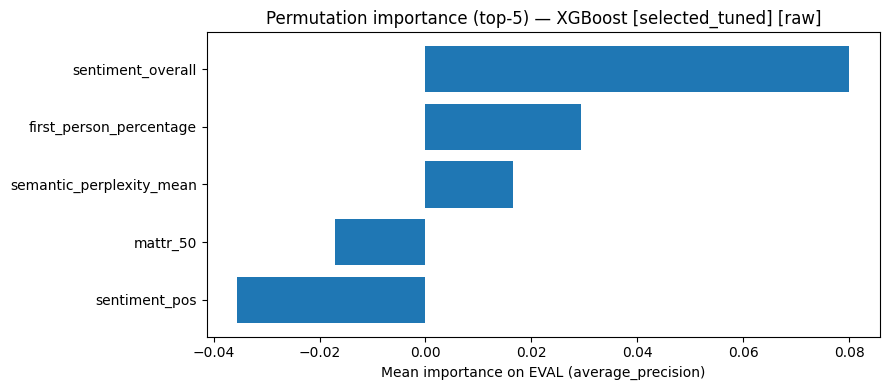


=== Summary metrics on TEST (tuned by PR AUC) ===
          target                   model                  variant  tuned  cv_best_score  cv_pr_auc_mean  cv_pr_auc_std                                                                                                                                                                          best_params  n_train  n_test  n_features_raw  n_features_selected  accuracy  f1_macro  f1_lo  f1_hi  balanced_acc  roc_auc  auc_lo  auc_hi  pr_auc  brier                                                                                                 selected_cols
Depression_label      LogisticRegression                     full  False            NaN          0.4212         0.0698                                                                                                                                                                                           219      56              20                  NaN    0.5893    0.5476 0.4199 0.6725        0.

In [8]:
res_b0_l_ptsd = run_models_pipeline_more_models_tuned_prauc(
    f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_bert_{LANGUAGE}_full{ITERATION}.csv",
    target_col="Depression_label",
    importance_top_k=5,
)

In [9]:
res_b0_l_ptsd

,target,model,variant,tuned,cv_best_score,cv_pr_auc_mean,cv_pr_auc_std,best_params,n_train,n_test,...,f1_macro,f1_lo,f1_hi,balanced_acc,roc_auc,auc_lo,auc_hi,pr_auc,brier,selected_cols
0,Depression_label,LogisticRegression,full,False,NaN,0.421244,0.069762,,219,56,...,0.547594,0.419939,0.672515,0.555807,0.559578,0.371041,0.740573,0.503629,0.264126,
1,Depression_label,LogisticRegression,"selected(top=5,corr<0.9)",False,NaN,0.408519,0.098782,,219,56,...,0.562500,0.441980,0.684245,0.609351,0.737557,0.567081,0.897436,0.723811,0.226350,"sentiment_neg,pause_variability,word_coherence..."
2,Depression_label,SVM,full_tuned,True,0.429009,0.429009,0.057395,"{'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__k...",219,56,...,0.635772,0.499015,0.763713,0.628959,0.361991,0.199057,0.526471,0.256743,0.221554,
3,Depression_label,SVM,selected_tuned,True,0.451305,0.451305,0.052355,"{'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__k...",219,56,...,0.425641,0.303349,0.549984,0.473605,0.564103,0.401207,0.733032,0.495857,0.208416,"sentiment_pos,words_per_min,phrase_repeat_perc..."
4,Depression_label,SGDClassifier(log_loss),full,False,NaN,0.396937,0.075435,,219,56,...,0.455556,0.334054,0.580952,0.458522,0.466063,0.304638,0.639555,0.315130,0.448351,
5,Depression_label,SGDClassifier(log_loss),"selected(top=5,corr<0.9)",False,NaN,0.299865,0.104384,,219,56,...,0.339075,0.213282,0.461538,0.409502,0.457014,0.269985,0.630505,0.375713,0.528978,"pause_variability,word_coherence_10_mean,senti..."
6,Depression_label,DecisionTree,full_tuned,True,0.349889,0.349889,0.068503,"{'clf__max_depth': 5, 'clf__min_samples_leaf':...",219,56,...,0.431250,0.317073,0.557956,0.434389,0.423831,0.278262,0.575434,0.280405,0.371356,
7,Depression_label,DecisionTree,selected_tuned,True,0.434732,0.434732,0.038110,"{'clf__max_depth': 5, 'clf__min_samples_leaf':...",219,56,...,0.461360,0.335968,0.596015,0.478884,0.416290,0.260162,0.577677,0.276288,0.364038,"words_per_min,pause_variability,sentiment_pos,..."
8,Depression_label,RandomForest,full_tuned,True,0.409492,0.409492,0.111323,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.510805,0.384615,0.644358,0.524133,0.570136,0.392157,0.751131,0.381270,0.216394,
9,Depression_label,RandomForest,selected_tuned,True,0.477797,0.477797,0.049010,"{'clf__bootstrap': True, 'clf__max_depth': Non...",219,56,...,0.487057,0.362602,0.619910,0.489442,0.493213,0.336350,0.654600,0.302050,0.240753,"sentiment_pos,sentiment_overall,semantic_perpl..."


# fusing pipeline

In [10]:
import warnings
warnings.filterwarnings("ignore")

from typing import Optional, Sequence, Dict, Any, List, Tuple
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    accuracy_score, f1_score, balanced_accuracy_score,
    classification_report, confusion_matrix
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, GridSearchCV

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
    xgb_available = True
except Exception:
    xgb_available = False


# -------------------------
# Bootstrap CIs (optional; оставил как у тебя)
# -------------------------
def bootstrap_ci_binary(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_proba: np.ndarray,
    metric: str,
    n_boot: int = 2000,
    seed: int = 1706,
    stratified: bool = True,
) -> Tuple[float, float, float]:
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_proba = np.asarray(y_proba)

    idx_pos = np.where(y_true == 1)[0]
    idx_neg = np.where(y_true == 0)[0]
    if len(idx_pos) == 0 or len(idx_neg) == 0:
        return float("nan"), float("nan"), float("nan")

    scores = []
    for _ in range(n_boot):
        if stratified:
            samp_pos = rng.choice(idx_pos, size=len(idx_pos), replace=True)
            samp_neg = rng.choice(idx_neg, size=len(idx_neg), replace=True)
            idx = np.concatenate([samp_pos, samp_neg])
        else:
            idx = rng.choice(len(y_true), size=len(y_true), replace=True)

        yt, yp, pr = y_true[idx], y_pred[idx], y_proba[idx]
        if metric == "f1_macro":
            s = f1_score(yt, yp, average="macro")
        elif metric == "auc":
            if len(np.unique(yt)) < 2:
                continue
            s = roc_auc_score(yt, pr)
        else:
            raise ValueError("metric must be 'f1_macro' or 'auc'")
        scores.append(s)

    if not scores:
        return float("nan"), float("nan"), float("nan")

    lo, hi = np.percentile(scores, [2.5, 97.5])
    return float(np.mean(scores)), float(lo), float(hi)


# -------------------------
# Clean, leakage-safe late fusion / stacking
# -------------------------
def run_late_fusion_pipeline_clean(
    dataset_b0_path: str,
    dataset_l_path: str,
    *,
    id_col: str = "Participant",
    target_col: str = "PTSD_label",
    split_col: str = "split",
    train_values: Sequence[str] = ("train", "dev"),
    test_value: str = "test",

    # model choice
    base_model_b0: str = "LogisticRegression",
    base_model_l: Optional[str] = None,  # if None -> same as base_model_b0
    meta_C: float = 1.0,

    # leakage-safe drops policy
    drop_demographics: bool = True,          # drop age/gender/sex by default
    extra_drop_common: Optional[Sequence[str]] = None,
    extra_drop_b0: Optional[Sequence[str]] = None,
    extra_drop_l: Optional[Sequence[str]] = None,

    # CV / OOF
    n_splits: int = 5,
    random_state: int = 1706,

    # tuning (if enabled, it will be NESTED in OOF; correct, but slower)
    tune_tree_models: bool = False,
    grid_scoring: str = "average_precision",
    grid_n_jobs: int = 1,
    grid_verbose: int = 0,

    # importance
    compute_importance: bool = True,
    perm_scoring: str = "average_precision",
    perm_n_repeats: int = 10,
    plot_top_k: int = 15,

    # metrics / CIs
    n_boot: int = 2000,
) -> pd.DataFrame:
    """
    What is guaranteed:
      - strict alignment B0<->L by id_col
      - automatic leakage-safe drop based on target_col:
          drops: id_col, split_col, target_col,
                 ALL other *_label / *_severity columns,
                 + optionally demographics
      - base models trained on train+dev; test evaluated on test
      - stacking uses OOF probabilities on train+dev (no test leakage)
      - permutation importance computed on RAW columns (clean and readable)
    """

    if base_model_l is None:
        base_model_l = base_model_b0

    extra_drop_common = list(extra_drop_common or [])
    extra_drop_b0 = list(extra_drop_b0 or [])
    extra_drop_l = list(extra_drop_l or [])

    # ---------- helpers ----------
    def _build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
        cat = [c for c in X.columns if X[c].dtype.name in ["object", "category", "bool"]]
        num = [c for c in X.columns if c not in cat]
        try:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        except TypeError:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

        return ColumnTransformer(
            transformers=[
                ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("ohe", ohe)]), cat),
                ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num),
            ],
            remainder="drop",
        )

    def _safe_n_splits(y: np.ndarray, desired: int) -> int:
        counts = Counter(y.tolist())
        min_class = min(counts.values()) if counts else 0
        return max(2, min(desired, min_class)) if min_class >= 2 else 0

    def _predict_proba(pipe: Pipeline, X: pd.DataFrame) -> np.ndarray:
        return pipe.predict_proba(X)[:, 1]



    def _best_threshold(y_true: np.ndarray, y_proba: np.ndarray, metric: str = "f1") -> float:
        thresholds = np.linspace(0.0, 1.0, 201)
        best_t = 0.5
        best_v = -np.inf
        for t in thresholds:
            y_hat = (y_proba >= t).astype(int)
            if metric == "balanced_acc":
                v = balanced_accuracy_score(y_true, y_hat)
            else:
                v = f1_score(y_true, y_hat, average="macro")
            if v > best_v:
                best_v = v
                best_t = t
        return float(best_t)

    def _metrics(y_true: np.ndarray, y_pred: np.ndarray, y_proba: np.ndarray) -> Dict[str, Any]:
        out = {
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "f1_macro": float(f1_score(y_true, y_pred, average="macro")),
            "balanced_acc": float(balanced_accuracy_score(y_true, y_pred)),
            "roc_auc": float(roc_auc_score(y_true, y_proba)) if len(np.unique(y_true)) == 2 else float("nan"),
            "pr_auc": float(average_precision_score(y_true, y_proba)) if len(np.unique(y_true)) == 2 else float("nan"),
            "brier": float(brier_score_loss(y_true, y_proba)),
            "f1_lo": float("nan"),
            "f1_hi": float("nan"),
            "auc_lo": float("nan"),
            "auc_hi": float("nan"),
        }
        # bootstrap CI
        if len(np.unique(y_true)) == 2:
            _, f1_lo, f1_hi = bootstrap_ci_binary(
                y_true, y_pred, y_proba, metric="f1_macro",
                n_boot=n_boot, seed=random_state
            )
            _, auc_lo, auc_hi = bootstrap_ci_binary(
                y_true, y_pred, y_proba, metric="auc",
                n_boot=n_boot, seed=random_state
            )
            out["f1_lo"], out["f1_hi"] = float(f1_lo), float(f1_hi)
            out["auc_lo"], out["auc_hi"] = float(auc_lo), float(auc_hi)
        return out

    def _perm_importance_raw(pipe_fitted: Pipeline, X_eval: pd.DataFrame, y_eval: np.ndarray, title: str) -> pd.DataFrame:
        perm = permutation_importance(
            pipe_fitted, X_eval, y_eval,
            n_repeats=perm_n_repeats,
            random_state=random_state,
            scoring=perm_scoring
        )
        perm_df = pd.DataFrame({
            "feature": list(X_eval.columns),
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

        print(f"\n[{title}] Top-{min(10, len(perm_df))} permutation importances ({perm_scoring}, raw):")
        print(perm_df.head(10).to_string(index=False))

        top_n = min(plot_top_k, len(perm_df))
        if top_n > 0:
            plt.figure(figsize=(9, max(4, 0.35 * top_n)))
            plt.barh(
                perm_df.loc[:top_n - 1, "feature"][::-1],
                perm_df.loc[:top_n - 1, "importance_mean"][::-1],
            )
            plt.title(f"Permutation importance (top-{top_n}) — {title} [raw]")
            plt.xlabel(f"Mean importance on EVAL ({perm_scoring})")
            plt.tight_layout()
            plt.show()

        return perm_df

    def _make_leakage_drop(df: pd.DataFrame) -> List[str]:
        # drop: id, split, target + all other *_label / *_severity columns
        drops = {id_col, split_col, target_col}

        for c in df.columns:
            lc = str(c).lower()
            if c == target_col:
                continue
            if lc.endswith("_label") or lc.endswith("_severity"):
                drops.add(c)

        if drop_demographics:
            for c in ["age", "gender", "sex"]:
                if c in df.columns:
                    drops.add(c)

        for c in extra_drop_common:
            if c in df.columns:
                drops.add(c)

        return sorted(drops)

    def _assert_no_leakage_cols(X: pd.DataFrame, df_ref: pd.DataFrame, where: str) -> None:
        forbidden = set(_make_leakage_drop(df_ref)) - {id_col, split_col}
        bad = forbidden.intersection(set(X.columns))
        if bad:
            raise ValueError(
                f"[LEAKAGE] Forbidden columns present in features at {where}: {sorted(bad)}. "
                f"Check drop policy / extra_drop_*."
            )

    def _get_estimator_and_grid(model_name: str, y_for_xgb: np.ndarray):
        name = model_name.strip()

        if name == "LogisticRegression":
            est = LogisticRegression(
                solver="lbfgs", max_iter=5000, class_weight="balanced",
                random_state=random_state
            )
            return est, {}

        if name in ["SVM", "SVC"]:
            est = SVC(
                kernel="rbf", C=1.0, gamma="scale", probability=True,
                class_weight="balanced", random_state=random_state
            )
            grid = {
                "C": [0.1, 1, 10],
                "gamma": ["scale", "auto"],
                "kernel": ["rbf", "linear"],
            }
            return est, grid

        if name == "SGDClassifier(log_loss)":
            est = SGDClassifier(
                loss="log_loss", penalty="l2", alpha=1e-4,
                max_iter=5000, tol=1e-3, class_weight="balanced",
                random_state=random_state
            )
            return est, {}

        if name == "DecisionTree":
            est = DecisionTreeClassifier(random_state=random_state, class_weight="balanced")
            grid = {
                "max_depth": [3, 5, 10, None],
                "min_samples_split": [2, 5, 10],
                "min_samples_leaf": [1, 2, 4, 8],
            }
            return est, grid

        if name == "RandomForest":
            est = RandomForestClassifier(random_state=random_state, class_weight="balanced", n_jobs=1)
            grid = {
                "n_estimators": [200, 500],
                "max_depth": [None, 5, 10],
                "min_samples_split": [2, 5, 10],
                "min_samples_leaf": [1, 2, 4],
                "max_features": ["sqrt", "log2", 0.5],
                "bootstrap": [True],
            }
            return est, grid

        if name == "XGBoost":
            if not xgb_available:
                raise RuntimeError("XGBoost requested but xgboost is not installed.")
            pos = int((y_for_xgb == 1).sum())
            neg = int((y_for_xgb == 0).sum())
            spw = float(neg / max(pos, 1)) if pos > 0 else 1.0
            est = XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=random_state,
                n_jobs=1,
                scale_pos_weight=spw,
            )
            grid = {
                "n_estimators": [200, 500],
                "max_depth": [3, 6, 10],
                "learning_rate": [0.03, 0.1],
                "subsample": [0.8, 1.0],
                "colsample_bytree": [0.8, 1.0],
                "min_child_weight": [1, 5],
                "reg_lambda": [1.0, 5.0],
            }
            return est, grid

        raise ValueError(
            f"Unknown model '{model_name}'. Use: LogisticRegression, SGDClassifier(log_loss), "
            f"DecisionTree, RandomForest, XGBoost"
        )

    def _fit_with_optional_tuning(pipe: Pipeline, grid: Dict[str, List[Any]], X_tr: pd.DataFrame, y_tr: np.ndarray) -> Tuple[Pipeline, Dict[str, Any], float, bool]:
        # tuning only for models that have a non-empty grid AND if enabled
        if (not tune_tree_models) or (not grid):
            pipe.fit(X_tr, y_tr)
            return pipe, {}, float("nan"), False

        k = _safe_n_splits(y_tr, n_splits)
        if k < 2:
            pipe.fit(X_tr, y_tr)
            return pipe, {}, float("nan"), False

        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
        gs = GridSearchCV(
            estimator=pipe,
            param_grid={f"clf__{k}": v for k, v in grid.items()},
            scoring=grid_scoring,
            cv=cv,
            n_jobs=grid_n_jobs,
            refit=True,
            verbose=grid_verbose,
            error_score=np.nan,
        )
        gs.fit(X_tr, y_tr)
        return gs.best_estimator_, gs.best_params_, float(gs.best_score_), True

    def _oof_proba_nested(
        model_name: str,
        X: pd.DataFrame,
        y: np.ndarray
    ) -> np.ndarray:
        """
        OOF probabilities on train+dev.
        Если tune_tree_models=True и для модели есть grid -> nested tuning внутри каждого фолда (корректно).
        """
        k = _safe_n_splits(y, n_splits)
        if k < 2:
            raise ValueError(
                f"Not enough samples per class for CV. "
                f"Counts={Counter(y.tolist())}. Reduce n_splits or get more data."
            )

        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
        oof = np.empty(len(y), dtype=float)

        for tr_idx, val_idx in cv.split(X, y):
            X_tr, y_tr = X.iloc[tr_idx], y[tr_idx]
            X_val = X.iloc[val_idx]

            est, grid = _get_estimator_and_grid(model_name, y_tr)
            pipe = Pipeline([("pre", _build_preprocessor(X_tr)), ("clf", clone(est))])

            # nested tuning
            pipe_best, _, _, _ = _fit_with_optional_tuning(pipe, grid, X_tr, y_tr)
            oof[val_idx] = _predict_proba(pipe_best, X_val)

        return oof

    def _fit_final_and_eval(
        title: str,
        model_name: str,
        X_tr: pd.DataFrame,
        y_tr: np.ndarray,
        X_te: pd.DataFrame,
        y_te: np.ndarray,
        df_ref_for_drop: pd.DataFrame,
    ) -> Dict[str, Any]:
        est, grid = _get_estimator_and_grid(model_name, y_tr)
        pipe = Pipeline([("pre", _build_preprocessor(X_tr)), ("clf", clone(est))])

        pipe_best, best_params, best_cv, tuned = _fit_with_optional_tuning(pipe, grid, X_tr, y_tr)

        p_te = _predict_proba(pipe_best, X_te)
        y_pred = (p_te >= 0.5).astype(int)

        print(f"\n=== {title}: {model_name} [{'tuned' if tuned else 'default'}] ===")
        if tuned:
            print("Best CV score:", round(best_cv, 4))
            print("Best params:", best_params)

        print("\nClassification report:\n", classification_report(y_te, y_pred, digits=3))
        print("Confusion matrix:\n", confusion_matrix(y_te, y_pred))

        perm_df = None
        if compute_importance:
            _assert_no_leakage_cols(X_tr, df_ref_for_drop, where=f"{title}/train")
            _assert_no_leakage_cols(X_te, df_ref_for_drop, where=f"{title}/test")
            perm_df = _perm_importance_raw(pipe_best, X_te, y_te, f"{title} ({model_name})")

        out = {
            "title": title,
            "model": model_name,
            "tuned": bool(tuned),
            "cv_best_score": float(best_cv),
            "best_params": str(best_params) if best_params else "",
            "n_train": int(len(y_tr)),
            "n_test": int(len(y_te)),
            "n_features_raw": int(X_tr.shape[1]),
            "pipe_final": pipe_best,
            "proba_test": p_te,
            "y_pred_test": y_pred,
            "perm_df": perm_df,
            **_metrics(y_te, y_pred, p_te),
        }
        return out

    # ---------- load + align ----------
    df_b0 = pd.read_csv(dataset_b0_path)
    df_l = pd.read_csv(dataset_l_path)

    # enforce string ids (safe for sorting)
    if id_col in df_b0.columns:
        df_b0[id_col] = df_b0[id_col].astype(str)
    if id_col in df_l.columns:
        df_l[id_col] = df_l[id_col].astype(str)

    if id_col not in df_b0.columns or id_col not in df_l.columns:
        raise KeyError(f"'{id_col}' must exist in both datasets for reliable fusion alignment.")

    common = sorted(set(df_b0[id_col]).intersection(set(df_l[id_col])))
    if len(common) == 0:
        raise ValueError(f"No overlapping '{id_col}' values between B0 and L datasets.")

    df_b0 = df_b0[df_b0[id_col].isin(common)].sort_values(id_col).reset_index(drop=True)
    df_l = df_l[df_l[id_col].isin(common)].sort_values(id_col).reset_index(drop=True)

    # strict asserts like in clean script
    if not np.array_equal(df_b0[id_col].values, df_l[id_col].values):
        raise ValueError("Alignment failed: id ordering mismatch after sorting/intersection.")
    if split_col not in df_b0.columns or split_col not in df_l.columns:
        raise KeyError(f"Missing '{split_col}' in one of datasets.")
    if target_col not in df_b0.columns or target_col not in df_l.columns:
        raise KeyError(f"Missing target '{target_col}' in one of datasets.")

    if not np.array_equal(df_b0[split_col].astype(str).values, df_l[split_col].astype(str).values):
        raise ValueError(f"Mismatch between B0 and L for column '{split_col}' after alignment.")
    if not np.array_equal(df_b0[target_col].astype(int).values, df_l[target_col].astype(int).values):
        raise ValueError(f"Mismatch between B0 and L for column '{target_col}' after alignment.")

    # ---------- train/dev vs test ----------
    split_lower = df_b0[split_col].astype(str).str.lower().str.strip()
    train_values_set = {str(v).lower() for v in train_values}
    is_train = split_lower.isin(train_values_set)
    is_test = split_lower.eq(str(test_value).lower())

    if is_train.sum() == 0 or is_test.sum() == 0:
        raise ValueError(
            f"Train/Test rows not found. train in {sorted(train_values_set)} count={is_train.sum()}, "
            f"test='{test_value}' count={is_test.sum()}."
        )

    y_train = df_b0.loc[is_train, target_col].astype(int).to_numpy()
    y_test = df_b0.loc[is_test, target_col].astype(int).to_numpy()

    # ---------- automatic leakage-safe drops ----------
    drop_common_b0 = _make_leakage_drop(df_b0)
    drop_common_l = _make_leakage_drop(df_l)
    drop_common = sorted(set(drop_common_b0).union(set(drop_common_l)))

    # apply extras
    drop_b0 = sorted(set(drop_common).union(set(extra_drop_b0)))
    drop_l = sorted(set(drop_common).union(set(extra_drop_l)))

    X_b0_train = df_b0.loc[is_train].drop(columns=drop_b0, errors="ignore")
    X_b0_test = df_b0.loc[is_test].drop(columns=drop_b0, errors="ignore")

    X_l_train = df_l.loc[is_train].drop(columns=drop_l, errors="ignore")
    X_l_test = df_l.loc[is_test].drop(columns=drop_l, errors="ignore")

    if X_b0_train.shape[1] == 0:
        raise ValueError("B0 features empty after dropping columns.")
    if X_l_train.shape[1] == 0:
        raise ValueError("L features empty after dropping columns.")

    # hard leakage asserts (ключевой фикс)
    _assert_no_leakage_cols(X_b0_train, df_b0, where="B0/train")
    _assert_no_leakage_cols(X_b0_test, df_b0, where="B0/test")
    _assert_no_leakage_cols(X_l_train, df_l, where="L/train")
    _assert_no_leakage_cols(X_l_test, df_l, where="L/test")

    # ---------- fit base models (train+dev -> test) ----------
    b0_out = _fit_final_and_eval(
        "B0 base", base_model_b0, X_b0_train, y_train, X_b0_test, y_test, df_b0
    )
    l_out = _fit_final_and_eval(
        "L base", base_model_l, X_l_train, y_train, X_l_test, y_test, df_l
    )

    # ---------- OOF probs for meta (clean stacking) ----------
    p_b0_oof = _oof_proba_nested(base_model_b0, X_b0_train, y_train)
    p_l_oof = _oof_proba_nested(base_model_l, X_l_train, y_train)

    X_meta_train = np.column_stack([p_b0_oof, p_l_oof])
    X_meta_test = np.column_stack([b0_out["proba_test"], l_out["proba_test"]])

    meta = LogisticRegression(
        solver="lbfgs",
        max_iter=5000,
        class_weight="balanced",
        C=float(meta_C),
        random_state=random_state,
    )
    meta.fit(X_meta_train, y_train)

    p_fused = meta.predict_proba(X_meta_test)[:, 1]
    best_t = _best_threshold(y_test, p_fused, metric="f1")
    y_fused = (p_fused >= best_t).astype(int)
    print("Best threshold (F1):", best_t)

    print("\n=== FUSED (meta LogisticRegression on [p_B0, p_L]) ===")
    print("Meta weights:", {
        "intercept": float(meta.intercept_[0]),
        "w_pB0": float(meta.coef_[0, 0]),
        "w_pL": float(meta.coef_[0, 1]),
    })
    print("\nClassification report:\n", classification_report(y_test, y_fused, digits=3))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_fused))

    plt.figure(figsize=(6, 4))
    plt.barh(["p_B0", "p_L"], [meta.coef_[0, 0], meta.coef_[0, 1]])
    plt.title("Meta LogisticRegression coefficients")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

    fused_metrics = _metrics(y_test, y_fused, p_fused)

    # ---------- summary table ----------
    rows = []
    for out in [b0_out, l_out]:
        rows.append({
            "stage": out["title"],
            "model": out["model"],
            "tuned": out["tuned"],
            "cv_best_score": out["cv_best_score"],
            "best_params": out["best_params"],
            "n_train": out["n_train"],
            "n_test": out["n_test"],
            "n_features_raw": out["n_features_raw"],
            **{k: out[k] for k in [
                "accuracy", "f1_macro", "f1_lo", "f1_hi",
                "balanced_acc", "roc_auc", "auc_lo", "auc_hi",
                "pr_auc", "brier"
            ]},
        })

    rows.append({
        "stage": "FUSED",
        "model": "MetaLogisticRegression",
        "tuned": False,
        "cv_best_score": float("nan"),
        "best_params": f"meta_C={meta_C}",
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
        "n_features_raw": 2,
        **fused_metrics,
    })

    res_df = pd.DataFrame(rows)[[
        "stage", "model", "tuned", "cv_best_score", "best_params",
        "n_train", "n_test", "n_features_raw",
        "accuracy", "f1_macro", "f1_lo", "f1_hi",
        "balanced_acc", "roc_auc", "auc_lo", "auc_hi",
        "pr_auc", "brier",
    ]]

    print("\n=== Summary metrics on TEST (tuned by PR AUC) ===")
    print(res_df.round(4).to_string(index=False))

    return res_df


# -------------------------
# Example usage
# -------------------------
# res = run_late_fusion_pipeline_clean(
#     dataset_b0_path="/mnt/data/dataset_B0_gemma_eng_test_small.csv",
#     dataset_l_path="/mnt/data/dataset_L_gemma_eng_add_small.csv",
#     target_col="PTSD_label",
#     base_model_b0="LogisticRegression",
#     base_model_l="LogisticRegression",
#     tune_tree_models=False,
#     compute_importance=True
# )



=== B0 base: LogisticRegression [default] ===

Classification report:
               precision    recall  f1-score   support

           0      0.800     0.615     0.696        39
           1      0.423     0.647     0.512        17

    accuracy                          0.625        56
   macro avg      0.612     0.631     0.604        56
weighted avg      0.686     0.625     0.640        56

Confusion matrix:
 [[24 15]
 [ 6 11]]

[B0 base (LogisticRegression)] Top-7 permutation importances (average_precision, raw):
                 feature  importance_mean  importance_std
           words_per_min         0.071638        0.058543
       pause_variability         0.062960        0.029142
       turn_length_words         0.040126        0.062785
  word_repeat_percentage         0.026740        0.044000
phrase_repeat_percentage         0.011180        0.073598
       speech_percentage        -0.002322        0.006473
       mean_pause_length        -0.004505        0.013148


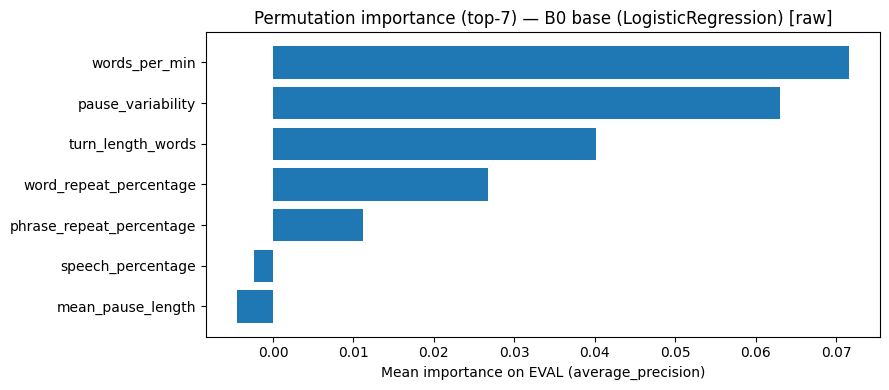


=== L base: LogisticRegression [default] ===

Classification report:
               precision    recall  f1-score   support

           0      0.708     0.436     0.540        39
           1      0.312     0.588     0.408        17

    accuracy                          0.482        56
   macro avg      0.510     0.512     0.474        56
weighted avg      0.588     0.482     0.500        56

Confusion matrix:
 [[17 22]
 [ 7 10]]

[L base (LogisticRegression)] Top-10 permutation importances (average_precision, raw):
                               feature  importance_mean  importance_std
                         sentiment_neg         0.216980        0.015689
                         sentiment_pos         0.124752        0.023567
                word_coherence_10_mean         0.109512        0.042115
               first_person_percentage         0.088445        0.032129
              semantic_perplexity_mean         0.072053        0.050113
                              mattr_50      

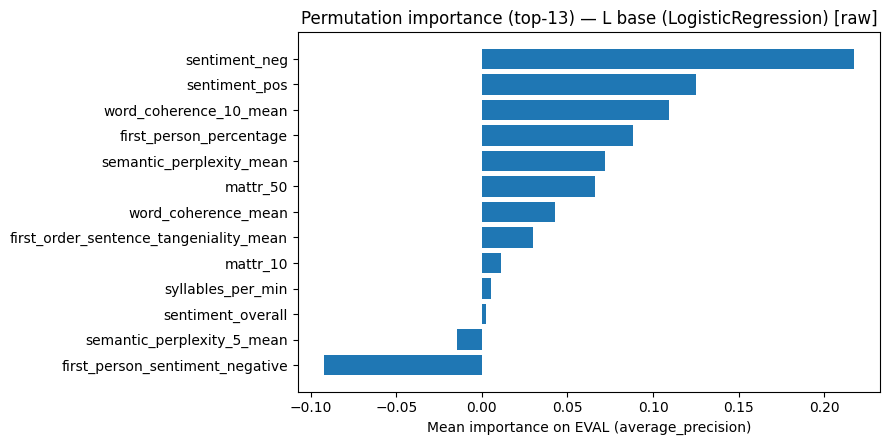

Best threshold (F1): 0.595

=== FUSED (meta LogisticRegression on [p_B0, p_L]) ===
Meta weights: {'intercept': -1.2834090188117944, 'w_pB0': 1.1383052343015991, 'w_pL': 1.5275126904825562}

Classification report:
               precision    recall  f1-score   support

           0      0.783     0.923     0.847        39
           1      0.700     0.412     0.519        17

    accuracy                          0.768        56
   macro avg      0.741     0.667     0.683        56
weighted avg      0.758     0.768     0.747        56

Confusion matrix:
 [[36  3]
 [10  7]]


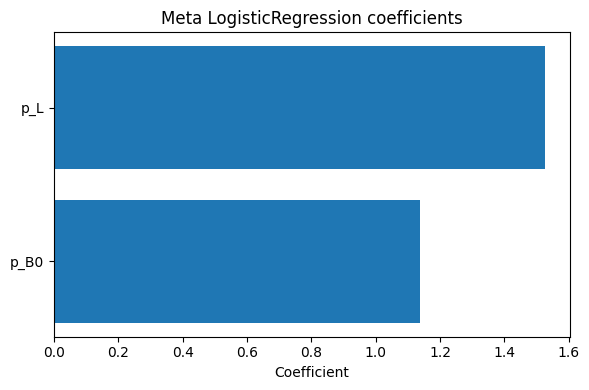


=== Summary metrics on TEST (tuned by PR AUC) ===
  stage                  model  tuned  cv_best_score best_params  n_train  n_test  n_features_raw  accuracy  f1_macro  f1_lo  f1_hi  balanced_acc  roc_auc  auc_lo  auc_hi  pr_auc  brier
B0 base     LogisticRegression  False            NaN                  219      56               7    0.6250    0.6036 0.4759 0.7278        0.6312   0.6275  0.4525  0.7889  0.4581 0.2463
 L base     LogisticRegression  False            NaN                  219      56              13    0.4821    0.4739 0.3497 0.5990        0.5121   0.5535  0.3665  0.7376  0.4659 0.2714
  FUSED MetaLogisticRegression  False            NaN  meta_C=1.0      219      56               2    0.7679    0.6828 0.5238 0.8095        0.6674   0.5988  0.4133  0.7738  0.5378 0.2472


In [11]:
res = run_late_fusion_pipeline_clean(
    dataset_b0_path=f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_bert_{LANGUAGE}_small_test{ITERATION}.csv",
    dataset_l_path=f"/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_bert_{LANGUAGE}_small_test{ITERATION}.csv",
    base_model_b0="LogisticRegression",
    base_model_l="LogisticRegression",
    tune_tree_models=False,
    compute_importance=True,
    # feature_selection=False,  # set True to do train-only raw-column selection per modality
    target_col='Depression_label',
)

In [12]:
res

,stage,model,tuned,cv_best_score,best_params,n_train,n_test,n_features_raw,accuracy,f1_macro,f1_lo,f1_hi,balanced_acc,roc_auc,auc_lo,auc_hi,pr_auc,brier
0,B0 base,LogisticRegression,False,NaN,,219,56,7,0.625000,0.603640,0.475886,0.727778,0.631222,0.627451,0.452489,0.788876,0.458127,0.246262
1,L base,LogisticRegression,False,NaN,,219,56,13,0.482143,0.473923,0.349677,0.598958,0.512066,0.553544,0.366516,0.737557,0.465930,0.271412
2,FUSED,MetaLogisticRegression,False,NaN,meta_C=1.0,219,56,2,0.767857,0.682789,0.523782,0.809524,0.667421,0.598793,0.413273,0.773793,0.537840,0.247168
